# Inseparable Frames Confound Score-RUM Learning

Empirical study based on §6 of the paper. The Score-RUM learner assumes perfectly separable priorities (§S-RUM). When an inseparable frame is present in the *true* generative model — even at modest weight — the learner is **confounded**: the MLE converges to a *persistently wrong* weight vector even with unlimited data.

**Setup (housing allocation, scale-free reduction):**
- 3 separable priorities: need, wait time, income fit. True weights $\beta^* = (0.5, 0.3, 0.2)$.
- 1 inseparable priority $u_C(F) = -\sum_g (p_g^F - \alpha_g)^2$ — a *distributional* concern (allocation should match target group proportions). $\alpha = (0.2, 0.3, 0.5)$ deliberately opposes the separable need priority.
- Effective weights: $\omega_j = \beta^*_j(1-\omega_C)$ for separable $j$, weight $\omega_C$ on $u_C$.
- Score-RUM learner fits $\hat\omega \in \Delta^2$ over the 3 separable features only — it has no representation for $u_C$.

**This notebook:**
1. Modularizes the simulation so we can vary the inseparable frame freely.
2. Replicates the baseline confounding result (Figure in §6).
3. **Pushes $\omega_C$ to extreme regimes** to show how *catastrophic* the confounding becomes.
4. **Sweeps adversarial $\alpha$ targets** — which distributional concerns confound learning worst?
5. **Adds a second inseparable frame** that pulls against the first — confounding doesn't necessarily cancel.


In [44]:
# Imports and global configuration
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from scipy.special import expit
from scipy.optimize import minimize

# ── Defaults (override per experiment) ─────────────────────────────────────
D_DEFAULT              = 3
BETA_STAR_DEFAULT      = np.array([0.5, 0.3, 0.2])
ALPHA_C_DEFAULT        = np.array([0.2, 0.3, 0.5])
N_INPUTS_DEFAULT       = 800
N_QUERIES_DEFAULT      = 3000
N_RUNS_DEFAULT         = 15      # bump to 60 for paper-quality figures
LOGISTIC_SCALE_DEFAULT = 0.3
QUERY_BATCH_DEFAULT    = 60
N_BG_DEFAULT           = 2000    # background rules for inseparable evidence

FEAT_NAMES  = [r"$\omega_1$: need", r"$\omega_2$: wait time", r"$\omega_3$: income fit"]
FEAT_COLORS = ["#D55E00", "#0072B2", "#009E73"]


## 1. Modular simulation infrastructure

Each function is parameterized so we can drop in different inseparable frames, target proportions $\alpha$, true separable weights $\beta^*$, etc.

In [45]:
# ── Feature sampling ─────────────────────────────────────────────────────
def sample_psi_raw(rng, n_inputs, D):
    """Raw features: group in {0,1,2} for psi_1, uniform[0,1] for others."""
    psi_raw = np.zeros((n_inputs, 2, D))
    psi_raw[:, :, 0] = rng.integers(0, 3, size=(n_inputs, 2)).astype(float)
    for j in range(1, D):
        psi_raw[:, :, j] = rng.uniform(0, 1, size=(n_inputs, 2))
    return psi_raw

def recode_psi(psi_raw):
    """Recode need: (2 - raw_group) / 2, so 1=high need, 0=low need."""
    psi = psi_raw.copy()
    psi[:, :, 0] = (2 - psi_raw[:, :, 0]) / 2.0
    return psi

def sep_gap(psi):
    """delta(x) = psi(x, y=1) - psi(x, y=0), shape (n_inputs, D)."""
    return psi[:, 1, :] - psi[:, 0, :]

# ── Inseparable evidence (single inseparable priority) ───────────────────
def compute_s_C(psi_raw, alpha, rng, n_bg=N_BG_DEFAULT):
    """
    For inseparable priority u_C(F) = -sum_g (p_g^F - alpha_g)^2,
    compute s_C_plus(x) and s_C_minus(x) via max over n_bg random background rules.
    alpha: shape (3,) target proportions.
    """
    n_inputs = psi_raw.shape[0]
    bg = rng.integers(0, 2, size=(n_bg, n_inputs))               # (n_bg, n_inputs)
    x_idx = np.arange(n_inputs)[None, :]
    chosen_g = psi_raw[x_idx, bg, 0].astype(int)                 # (n_bg, n_inputs)

    bar_p = np.zeros((n_bg, 3))
    for g in range(3):
        bar_p[:, g] = (chosen_g == g).mean(axis=1)

    gA = psi_raw[:, 0, 0].astype(int)
    gB = psi_raw[:, 1, 0].astype(int)

    sp = np.zeros(n_inputs); sm = np.zeros(n_inputs)
    for x in range(n_inputs):
        gc = chosen_g[:, x]
        bB = bar_p.copy()
        bB[np.arange(n_bg), gc]     -= 1.0 / n_inputs
        bB[np.arange(n_bg), gB[x]] += 1.0 / n_inputs
        bA = bar_p.copy()
        bA[np.arange(n_bg), gc]     -= 1.0 / n_inputs
        bA[np.arange(n_bg), gA[x]] += 1.0 / n_inputs
        uCB = -np.sum((bB - alpha) ** 2, axis=1)
        uCA = -np.sum((bA - alpha) ** 2, axis=1)
        d = uCB - uCA
        sp[x] = max(d.max(), 0.0)
        sm[x] = max((-d).max(), 0.0)
    return sp, sm

# ── Response generation: supports MULTIPLE inseparable frames ────────────
def generate_responses(psi, xs, omega_sep, inseparable_contribs, rng,
                       noise_scale=LOGISTIC_SCALE_DEFAULT):
    """
    inseparable_contribs: list of (omega_C, sp, sm) tuples — one per inseparable
    frame. omega_sep: (D,) array of separable weights (NOT necessarily summing
    to anything specific).
    """
    d = sep_gap(psi)[xs]
    g_sep = (omega_sep * np.maximum(d, 0)).sum(1) - (omega_sep * np.maximum(-d, 0)).sum(1)
    g_C = np.zeros_like(g_sep)
    for omega_C, sp, sm in inseparable_contribs:
        g_C = g_C + omega_C * (sp[xs] - sm[xs])
    g = g_sep + g_C
    prob = expit(g / noise_scale)
    return np.where(rng.uniform(size=len(xs)) < prob, 1, -1)

# ── Score-RUM MLE ────────────────────────────────────────────────────────
def fit_score_rum(deltas, responses, noise_scale=LOGISTIC_SCALE_DEFAULT):
    """Fit omega on the simplex by softmax parameterization + L-BFGS-B."""
    D = deltas.shape[1]
    labels = (responses + 1) / 2
    def obj(raw):
        b = np.exp(raw); b /= b.sum()
        g = (deltas @ b) / noise_scale
        p = expit(g)
        ll = (labels * np.log(p + 1e-15) + (1 - labels) * np.log(1 - p + 1e-15)).mean()
        res = p - labels
        gb = (res[:, None] * deltas).mean(0) / noise_scale
        J = np.diag(b) - np.outer(b, b)
        return -ll, J @ gb
    r = minimize(obj, np.zeros(D), jac=True, method='L-BFGS-B',
                 options={'maxiter': 600, 'ftol': 1e-13})
    b = np.exp(r.x); b /= b.sum()
    return b

# ── Welfare metric ───────────────────────────────────────────────────────
def weighted_disagreement(psi, hat_omega_scaled, omega_sep):
    d = sep_gap(psi)
    score_true = d @ omega_sep
    score_hat  = d @ hat_omega_scaled
    disagree = (score_true > 0) != (score_hat > 0)
    gap = np.abs(score_true)
    denom = gap.sum()
    return 0.0 if denom < 1e-10 else gap[disagree].sum() / denom

# ── Single trial ─────────────────────────────────────────────────────────
def run_one(beta_star, omega_C, alpha, n_queries, n_inputs, noise_scale,
            seed, n_bg=N_BG_DEFAULT, query_batch=QUERY_BATCH_DEFAULT,
            extra_inseparable=None):
    """
    extra_inseparable: optional list of (omega, alpha) for ADDITIONAL inseparable
    frames beyond the primary one parameterized by (omega_C, alpha).
    """
    rng = np.random.default_rng(seed)
    D = len(beta_star)
    psi_raw = sample_psi_raw(rng, n_inputs, D)
    psi = recode_psi(psi_raw)
    sp1, sm1 = compute_s_C(psi_raw, alpha, rng, n_bg=n_bg)
    inseparable = [(omega_C, sp1, sm1)]
    if extra_inseparable is not None:
        for (omega_extra, alpha_extra) in extra_inseparable:
            sp_e, sm_e = compute_s_C(psi_raw, alpha_extra, rng, n_bg=n_bg)
            inseparable.append((omega_extra, sp_e, sm_e))
    # Effective separable weight scaling: keep the inseparable + separable
    # weights summing to 1 by construction.
    total_inseparable = omega_C + sum(o for o, _ in (extra_inseparable or []))
    assert total_inseparable <= 1.0 + 1e-8, "inseparable weights exceed 1"
    omega_sep = beta_star * (1 - total_inseparable)
    xs = rng.integers(0, n_inputs, size=n_queries)
    responses = generate_responses(psi, xs, omega_sep, inseparable, rng, noise_scale)
    deltas = sep_gap(psi)[xs]
    checkpoints = list(range(query_batch, n_queries + 1, query_batch))
    traj_omega = np.zeros((len(checkpoints), D))
    traj_wdf = np.zeros(len(checkpoints))
    for ci, cp in enumerate(checkpoints):
        ho = fit_score_rum(deltas[:cp], responses[:cp], noise_scale)
        traj_omega[ci] = ho
        traj_wdf[ci] = weighted_disagreement(psi, ho * (1 - total_inseparable), omega_sep)
    return checkpoints, traj_omega, traj_wdf

# ── Sweep over omega_C values ────────────────────────────────────────────
def run_sweep(omega_C_values, alpha, beta_star=None, n_runs=N_RUNS_DEFAULT,
              n_queries=N_QUERIES_DEFAULT, n_inputs=N_INPUTS_DEFAULT,
              noise_scale=LOGISTIC_SCALE_DEFAULT, base_seed=42,
              extra_inseparable=None, verbose=True):
    if beta_star is None:
        beta_star = BETA_STAR_DEFAULT
    results = {}
    for omega_C in omega_C_values:
        if verbose:
            print(f"  omega_C = {omega_C:.3f}", flush=True)
        trajs_o, trajs_w = [], []
        for run_i in range(n_runs):
            seed = base_seed + int(omega_C * 10000) + run_i * 17
            chk, to, tw = run_one(beta_star, omega_C, alpha, n_queries,
                                  n_inputs, noise_scale, seed,
                                  extra_inseparable=extra_inseparable)
            trajs_o.append(to); trajs_w.append(tw)
        results[omega_C] = (chk, np.array(trajs_o), np.array(trajs_w))
    return results

# ── Plotting ─────────────────────────────────────────────────────────────
def plot_sweep(results, beta_star=None, title="", save_path=None,
               show_wdf=True):
    if beta_star is None:
        beta_star = BETA_STAR_DEFAULT
    D = len(beta_star)
    omega_C_values = sorted(results.keys())
    n_cols = len(omega_C_values)
    n_rows = 3 if show_wdf else 2

    fig = plt.figure(figsize=(3.7 * n_cols, 2.5 * n_rows))
    gs = gridspec.GridSpec(n_rows, n_cols, hspace=0.45, wspace=0.28,
                           left=0.07, right=0.98, top=0.88, bottom=0.10)

    for col, omega_C in enumerate(omega_C_values):
        chk, all_o, all_w = results[omega_C]
        mean_o = all_o.mean(0); std_o = all_o.std(0)
        mean_w = all_w.mean(0); std_w = all_w.std(0)
        n_queries = int(chk[-1])
        xs_plt = np.array(chk) / n_queries

        # Row 0: weight trajectories
        ax = fig.add_subplot(gs[0, col])
        for j in range(D):
            ax.plot(xs_plt, mean_o[:, j], color=FEAT_COLORS[j], lw=2.0)
            ax.fill_between(xs_plt, mean_o[:, j] - std_o[:, j],
                            mean_o[:, j] + std_o[:, j],
                            color=FEAT_COLORS[j], alpha=0.18)
            ax.axhline(beta_star[j], color=FEAT_COLORS[j], ls='--', lw=1.0, alpha=0.6)
        ax.set_ylim(-0.05, 1.05); ax.set_xlim(0, 1)
        ax.set_title(rf"$\omega_C = {omega_C}$", fontsize=11, fontweight='bold')
        if col == 0:
            ax.set_ylabel(r"learned $\hat\omega_j$", fontsize=10)
        ax.grid(alpha=0.3)

        # Row 1: L1 error
        ax2 = fig.add_subplot(gs[1, col])
        l1_runs = np.abs(all_o - beta_star[None, None, :]).sum(axis=2)
        mean_l1 = l1_runs.mean(0); std_l1 = l1_runs.std(0)
        ax2.fill_between(xs_plt, np.maximum(mean_l1 - std_l1, 0),
                         mean_l1 + std_l1, color='#CC79A7', alpha=0.22)
        ax2.plot(xs_plt, mean_l1, color='#CC79A7', lw=2.0)
        ax2.set_ylim(0, None); ax2.set_xlim(0, 1)
        if col == 0:
            ax2.set_ylabel(r"$\|\hat\omega - \beta^*\|_1$", fontsize=10)
        ax2.grid(alpha=0.3)

        # Row 2: weighted disagreement fraction
        if show_wdf:
            ax3 = fig.add_subplot(gs[2, col])
            ax3.fill_between(xs_plt, np.maximum(mean_w - std_w, 0),
                             mean_w + std_w, color='#E69F00', alpha=0.22)
            ax3.plot(xs_plt, mean_w, color='#E69F00', lw=2.0)
            ax3.set_ylim(0, None); ax3.set_xlim(0, 1)
            if col == 0:
                ax3.set_ylabel("weighted\ndisagreement", fontsize=10)
            ax3.set_xlabel("fraction of queries", fontsize=9)
            ax3.grid(alpha=0.3)
        else:
            ax2.set_xlabel("fraction of queries", fontsize=9)

    # Legend
    handles = [Line2D([0], [0], color=FEAT_COLORS[j], lw=2.0, label=FEAT_NAMES[j])
               for j in range(D)]
    handles += [Line2D([0], [0], color='#888', lw=1.0, ls='--', label=r'true $\beta^*_j$')]
    fig.legend(handles=handles, loc='upper center', ncol=4, fontsize=10,
               frameon=False, bbox_to_anchor=(0.5, 0.97))
    if title:
        fig.suptitle(title, y=1.0, fontsize=12, fontweight='bold')
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"saved {save_path}")
    plt.show()


## 2. Baseline: replicate the §6 figure

Original setup: $\omega_C \in \{0, 0.2, 0.4, 0.6\}$, $\alpha = (0.2, 0.3, 0.5)$. At $\omega_C = 0$ the learner recovers $\beta^*$ exactly. As $\omega_C$ grows, the MLE converges to a persistently wrong vector — need is systematically *under*-weighted because the inseparable frame keeps producing evidence *against* high-need allocations.

(Smaller `n_runs` here for speed; bump to 60 for paper-quality.)

Baseline sweep (omega_C = 0.0, 0.2, 0.4, 0.6)...
  omega_C = 0.000
  omega_C = 0.200
  omega_C = 0.400
  omega_C = 0.600
saved confounding_baseline.png


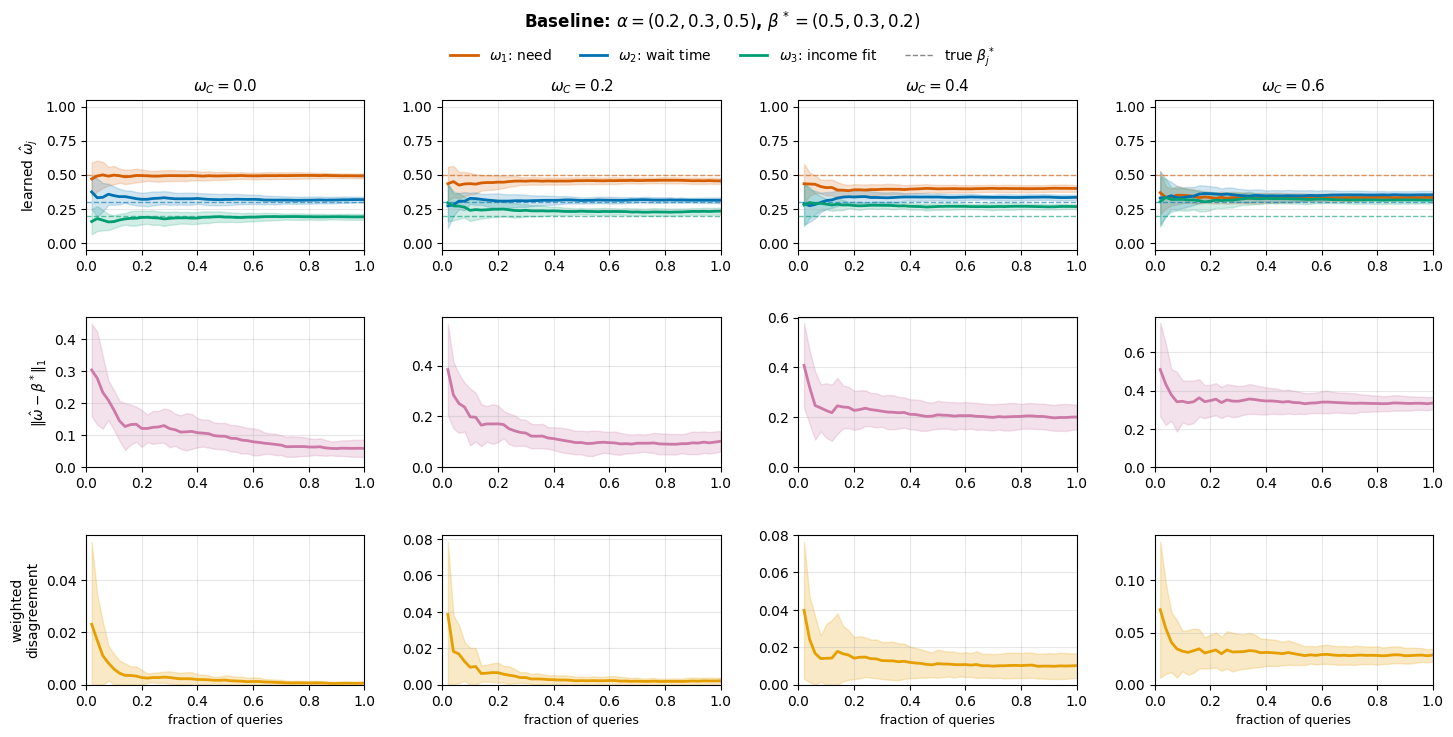

In [46]:
# Baseline sweep — original config
print("Baseline sweep (omega_C = 0.0, 0.2, 0.4, 0.6)...")
baseline = run_sweep(
    omega_C_values=[0.0, 0.2, 0.4, 0.6],
    alpha=ALPHA_C_DEFAULT,
    n_runs=15,        # bump to 60 for paper figures
    n_queries=3000,
)
plot_sweep(baseline,
           title=r"Baseline: $\alpha = (0.2, 0.3, 0.5)$, $\beta^* = (0.5, 0.3, 0.2)$",
           save_path="confounding_baseline.png")


## 3. How bad can it get? Push $\omega_C$ to extreme regimes

The original sweep stops at $\omega_C = 0.6$. Let's push it to where the inseparable frame dominates the response.

Extreme sweep (omega_C = 0.7, 0.85, 0.95, 0.99)...
  omega_C = 0.700
  omega_C = 0.850
  omega_C = 0.950
  omega_C = 0.990
saved confounding_extreme.png


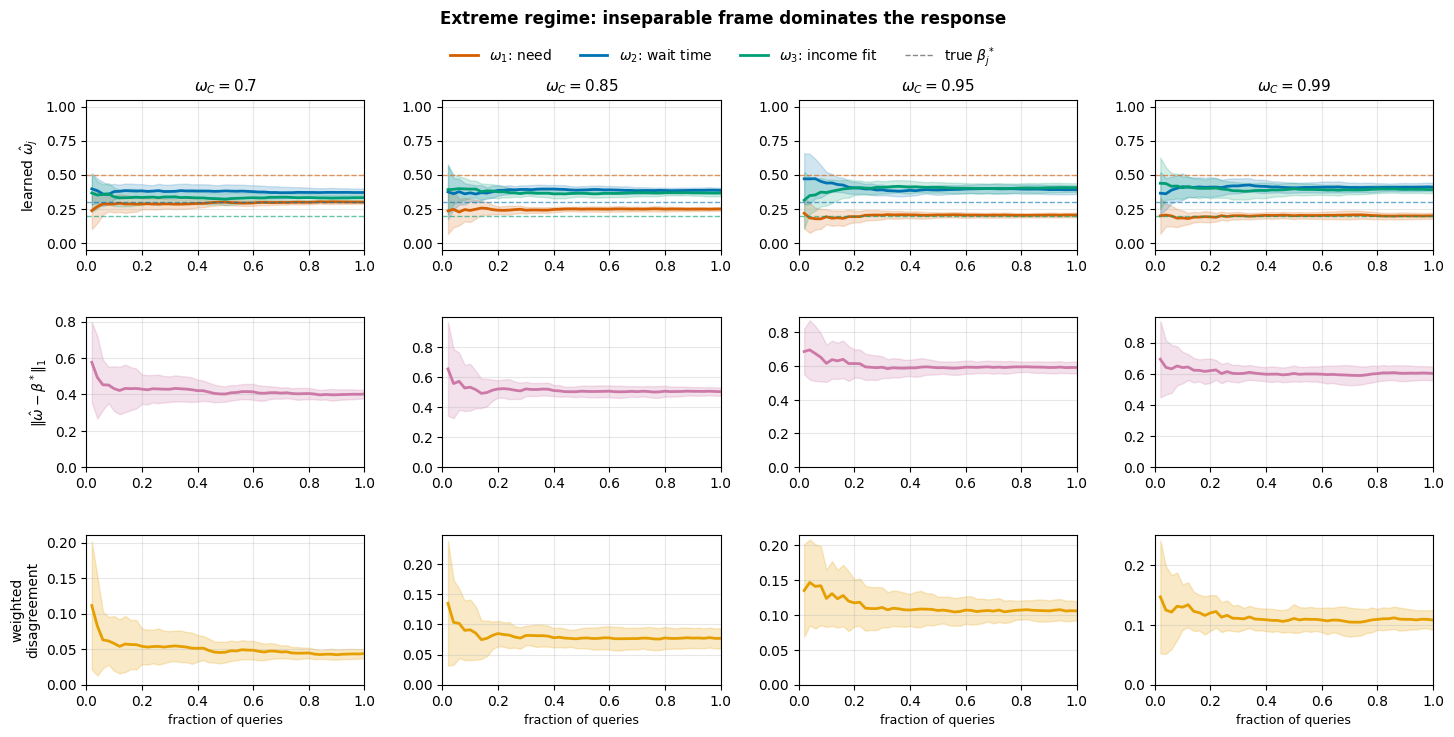


Final-checkpoint mean learned omega vs. true beta*:
  true beta*: [0.5 0.3 0.2]
  omega_C=0.70: hat_omega=[0.299 0.37  0.331], L1=0.402, WDF=0.044
  omega_C=0.85: hat_omega=[0.249 0.386 0.366], L1=0.502, WDF=0.077
  omega_C=0.95: hat_omega=[0.204 0.39  0.406], L1=0.592, WDF=0.106
  omega_C=0.99: hat_omega=[0.199 0.409 0.391], L1=0.602, WDF=0.108


In [47]:
# Push omega_C high — does the learner completely lose the signal?
print("Extreme sweep (omega_C = 0.7, 0.85, 0.95, 0.99)...")
extreme = run_sweep(
    omega_C_values=[0.7, 0.85, 0.95, 0.99],
    alpha=ALPHA_C_DEFAULT,
    n_runs=12,
    n_queries=3000,
)
plot_sweep(extreme,
           title=r"Extreme regime: inseparable frame dominates the response",
           save_path="confounding_extreme.png")

# Print MLE limits per omega_C
print()
print("Final-checkpoint mean learned omega vs. true beta*:")
print(f"  true beta*: {BETA_STAR_DEFAULT}")
for omega_C in sorted(extreme.keys()):
    _, all_o, all_w = extreme[omega_C]
    final = all_o[:, -1, :].mean(0)
    l1 = np.abs(final - BETA_STAR_DEFAULT).sum()
    wdf = all_w[:, -1].mean()
    print(f"  omega_C={omega_C:.2f}: hat_omega={final.round(3)}, L1={l1:.3f}, WDF={wdf:.3f}")


## 4. Adversarial $\alpha$ — which target proportions confound the worst?

The original $\alpha = (0.2, 0.3, 0.5)$ targets *low-need* applicants. What if the inseparable frame targets a *different* group? Does it confound differently?

We hold $\omega_C = 0.4$ fixed and sweep $\alpha$:
- $\alpha = (0.2, 0.3, 0.5)$: targets low-need (original)
- $\alpha = (0.5, 0.3, 0.2)$: targets *high-need* (aligned with $\beta^*$)
- $\alpha = (1/3, 1/3, 1/3)$: uniform target
- $\alpha = (0.5, 0.0, 0.5)$: bimodal — wants extremes, ignores middle


Alpha sweep at omega_C = 0.4...
  alpha = [0.2 0.3 0.5]: 'low-need
target (orig)'
  alpha = [0.5 0.3 0.2]: 'high-need
target (aligned)'
  alpha = [0.33333333 0.33333333 0.33333333]: 'uniform
target'
  alpha = [0.5 0.  0.5]: 'bimodal
target'


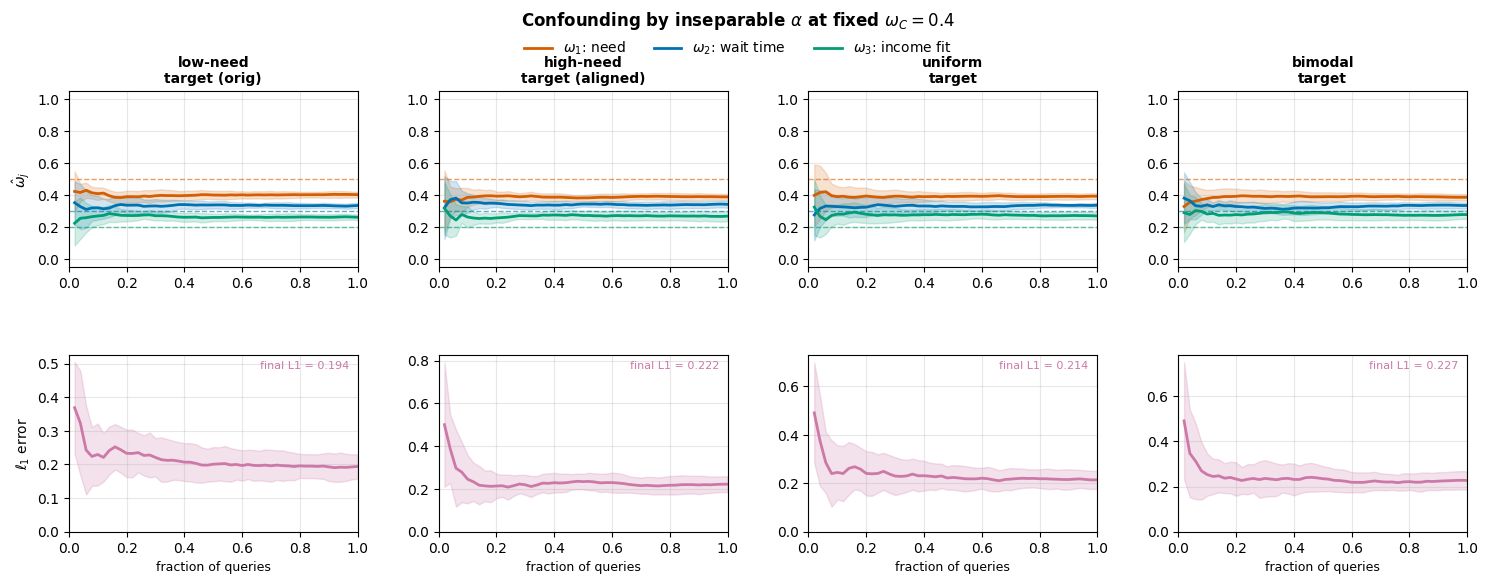


Final L1 by alpha (lower = less confounded):
  alpha low-need target (orig): hat_omega = [0.403 0.335 0.262], L1 = 0.194
  alpha high-need target (aligned): hat_omega = [0.389 0.342 0.269], L1 = 0.222
  alpha uniform target: hat_omega = [0.393 0.337 0.27 ], L1 = 0.214
  alpha bimodal target: hat_omega = [0.387 0.335 0.278], L1 = 0.227


In [48]:
# Adversarial alpha sweep — vary target proportions, hold omega_C fixed
print("Alpha sweep at omega_C = 0.4...")
ALPHA_CONFIGS = {
    'low-need\ntarget (orig)':  np.array([0.2, 0.3, 0.5]),
    'high-need\ntarget (aligned)': np.array([0.5, 0.3, 0.2]),
    'uniform\ntarget':          np.array([1/3, 1/3, 1/3]),
    'bimodal\ntarget':          np.array([0.5, 0.0, 0.5]),
}

alpha_results = {}
for label, alpha in ALPHA_CONFIGS.items():
    print(f"  alpha = {alpha}: '{label}'")
    res = run_sweep(
        omega_C_values=[0.4],
        alpha=alpha,
        n_runs=12,
        n_queries=3000,
        base_seed=hash(label) % 10000,
        verbose=False,
    )
    alpha_results[label] = res[0.4]

# Plot: one column per alpha config
fig = plt.figure(figsize=(3.8 * len(ALPHA_CONFIGS), 5.8))
gs = gridspec.GridSpec(2, len(ALPHA_CONFIGS), hspace=0.5, wspace=0.28,
                       left=0.06, right=0.98, top=0.86, bottom=0.10)

for col, (label, (chk, all_o, all_w)) in enumerate(alpha_results.items()):
    mean_o = all_o.mean(0); std_o = all_o.std(0)
    xs_plt = np.array(chk) / int(chk[-1])

    # Row 0: trajectories
    ax = fig.add_subplot(gs[0, col])
    for j in range(3):
        ax.plot(xs_plt, mean_o[:, j], color=FEAT_COLORS[j], lw=2.0)
        ax.fill_between(xs_plt, mean_o[:, j] - std_o[:, j],
                        mean_o[:, j] + std_o[:, j],
                        color=FEAT_COLORS[j], alpha=0.18)
        ax.axhline(BETA_STAR_DEFAULT[j], color=FEAT_COLORS[j], ls='--', lw=1.0, alpha=0.6)
    ax.set_ylim(-0.05, 1.05); ax.set_xlim(0, 1)
    ax.set_title(label, fontsize=10, fontweight='bold')
    if col == 0:
        ax.set_ylabel(r"$\hat\omega_j$", fontsize=10)
    ax.grid(alpha=0.3)

    # Row 1: L1 error
    ax2 = fig.add_subplot(gs[1, col])
    l1_runs = np.abs(all_o - BETA_STAR_DEFAULT[None, None, :]).sum(axis=2)
    ax2.plot(xs_plt, l1_runs.mean(0), color='#CC79A7', lw=2.0)
    ax2.fill_between(xs_plt,
                     np.maximum(l1_runs.mean(0) - l1_runs.std(0), 0),
                     l1_runs.mean(0) + l1_runs.std(0),
                     color='#CC79A7', alpha=0.22)
    ax2.set_ylim(0, None); ax2.set_xlim(0, 1)
    if col == 0:
        ax2.set_ylabel(r"$\ell_1$ error", fontsize=10)
    ax2.set_xlabel("fraction of queries", fontsize=9)
    ax2.grid(alpha=0.3)

    # Annotation
    final_l1 = l1_runs[:, -1].mean()
    ax2.annotate(f"final L1 = {final_l1:.3f}",
                 xy=(0.97, 0.97), xycoords='axes fraction',
                 ha='right', va='top', fontsize=8, color='#CC79A7')

handles = [Line2D([0], [0], color=FEAT_COLORS[j], lw=2.0, label=FEAT_NAMES[j])
           for j in range(3)]
fig.legend(handles=handles, loc='upper center', ncol=3, fontsize=10,
           frameon=False, bbox_to_anchor=(0.5, 0.97))
fig.suptitle(r"Confounding by inseparable $\alpha$ at fixed $\omega_C = 0.4$",
             y=1.0, fontsize=12, fontweight='bold')
plt.savefig("confounding_alpha_sweep.png", dpi=150, bbox_inches='tight')
plt.show()

# Print final L1s for ranking
print("\nFinal L1 by alpha (lower = less confounded):")
for label, (_, all_o, _) in alpha_results.items():
    final = all_o[:, -1, :].mean(0)
    l1 = np.abs(final - BETA_STAR_DEFAULT).sum()
    print(f"  alpha {label.replace(chr(10),' ')}: hat_omega = {final.round(3)}, L1 = {l1:.3f}")


## 5. Two inseparable frames pulling in opposite directions

What if there are *two* inseparable frames? Do their confounding effects cancel, or compound?

We add a second inseparable frame that targets the *opposite* group from the first:
- Frame 1: $\alpha_1 = (0.2, 0.3, 0.5)$, weight $\omega_{C_1}$ (low-need target)
- Frame 2: $\alpha_2 = (0.5, 0.3, 0.2)$, weight $\omega_{C_2}$ (high-need target, aligned with $\beta^*$)

We sweep different $(\omega_{C_1}, \omega_{C_2})$ pairs to see whether opposing inseparable frames cancel.

Two-inseparable-frame sweep...
  $\omega_{C_1} = 0.4$, $\omega_{C_2} = 0.0$
  $\omega_{C_1} = 0.0$, $\omega_{C_2} = 0.4$
  $\omega_{C_1} = 0.3$, $\omega_{C_2} = 0.3$
  $\omega_{C_1} = 0.2$, $\omega_{C_2} = 0.4$


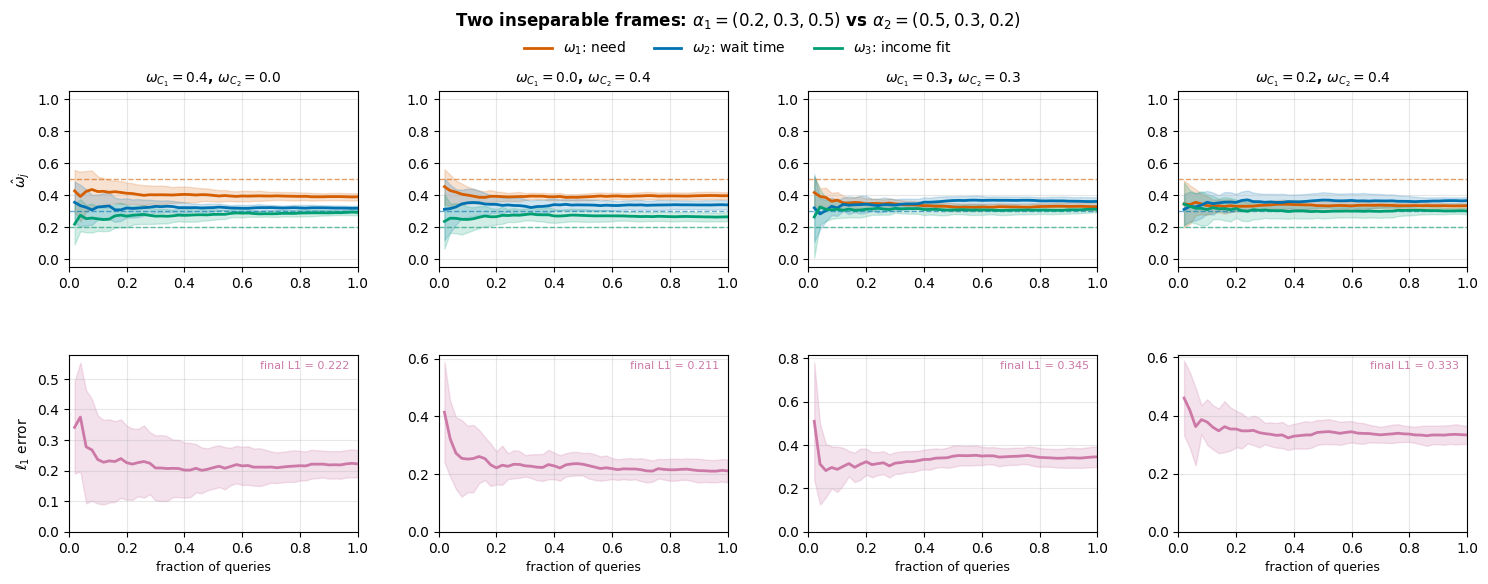


Final hat_omega and L1 for each (omega_C1, omega_C2):
  (0.4, 0.0): hat_omega = [0.389 0.318 0.292], L1 = 0.221
  (0.0, 0.4): hat_omega = [0.396 0.339 0.265], L1 = 0.207
  (0.3, 0.3): hat_omega = [0.327 0.36  0.312], L1 = 0.345
  (0.2, 0.4): hat_omega = [0.333 0.365 0.301], L1 = 0.333


In [49]:
# Two opposing inseparable frames
print("Two-inseparable-frame sweep...")
ALPHA_LOW  = np.array([0.2, 0.3, 0.5])   # low-need target (opposes beta*)
ALPHA_HIGH = np.array([0.5, 0.3, 0.2])   # high-need target (aligns with beta*)

PAIRS = [
    (0.4, 0.0),    # frame 1 alone
    (0.0, 0.4),    # frame 2 alone
    (0.3, 0.3),    # both at equal weight
    (0.2, 0.4),    # frame 2 dominates
]

two_frame_results = {}
for (o1, o2) in PAIRS:
    label = rf"$\omega_{{C_1}} = {o1}$, $\omega_{{C_2}} = {o2}$"
    print(f"  {label}")
    res = run_sweep(
        omega_C_values=[o1],
        alpha=ALPHA_LOW,
        n_runs=10,
        n_queries=3000,
        extra_inseparable=[(o2, ALPHA_HIGH)] if o2 > 0 else None,
        base_seed=hash((o1, o2)) % 10000,
        verbose=False,
    )
    two_frame_results[(o1, o2)] = res[o1]

# Plot
fig = plt.figure(figsize=(3.8 * len(PAIRS), 5.8))
gs = gridspec.GridSpec(2, len(PAIRS), hspace=0.5, wspace=0.28,
                       left=0.06, right=0.98, top=0.86, bottom=0.10)

for col, ((o1, o2), (chk, all_o, all_w)) in enumerate(two_frame_results.items()):
    mean_o = all_o.mean(0); std_o = all_o.std(0)
    xs_plt = np.array(chk) / int(chk[-1])

    ax = fig.add_subplot(gs[0, col])
    for j in range(3):
        ax.plot(xs_plt, mean_o[:, j], color=FEAT_COLORS[j], lw=2.0)
        ax.fill_between(xs_plt, mean_o[:, j] - std_o[:, j],
                        mean_o[:, j] + std_o[:, j],
                        color=FEAT_COLORS[j], alpha=0.18)
        ax.axhline(BETA_STAR_DEFAULT[j], color=FEAT_COLORS[j], ls='--', lw=1.0, alpha=0.6)
    ax.set_ylim(-0.05, 1.05); ax.set_xlim(0, 1)
    ax.set_title(rf"$\omega_{{C_1}}={o1}$, $\omega_{{C_2}}={o2}$",
                 fontsize=10, fontweight='bold')
    if col == 0:
        ax.set_ylabel(r"$\hat\omega_j$", fontsize=10)
    ax.grid(alpha=0.3)

    ax2 = fig.add_subplot(gs[1, col])
    l1_runs = np.abs(all_o - BETA_STAR_DEFAULT[None, None, :]).sum(axis=2)
    ax2.plot(xs_plt, l1_runs.mean(0), color='#CC79A7', lw=2.0)
    ax2.fill_between(xs_plt,
                     np.maximum(l1_runs.mean(0) - l1_runs.std(0), 0),
                     l1_runs.mean(0) + l1_runs.std(0),
                     color='#CC79A7', alpha=0.22)
    ax2.set_ylim(0, None); ax2.set_xlim(0, 1)
    if col == 0:
        ax2.set_ylabel(r"$\ell_1$ error", fontsize=10)
    ax2.set_xlabel("fraction of queries", fontsize=9)
    ax2.grid(alpha=0.3)
    final_l1 = l1_runs[:, -1].mean()
    ax2.annotate(f"final L1 = {final_l1:.3f}",
                 xy=(0.97, 0.97), xycoords='axes fraction',
                 ha='right', va='top', fontsize=8, color='#CC79A7')

handles = [Line2D([0], [0], color=FEAT_COLORS[j], lw=2.0, label=FEAT_NAMES[j])
           for j in range(3)]
fig.legend(handles=handles, loc='upper center', ncol=3, fontsize=10,
           frameon=False, bbox_to_anchor=(0.5, 0.97))
fig.suptitle(r"Two inseparable frames: $\alpha_1=(0.2,0.3,0.5)$ vs $\alpha_2=(0.5,0.3,0.2)$",
             y=1.0, fontsize=12, fontweight='bold')
plt.savefig("confounding_two_frames.png", dpi=150, bbox_inches='tight')
plt.show()

print()
print("Final hat_omega and L1 for each (omega_C1, omega_C2):")
for (o1, o2), (_, all_o, _) in two_frame_results.items():
    final = all_o[:, -1, :].mean(0)
    l1 = np.abs(final - BETA_STAR_DEFAULT).sum()
    print(f"  ({o1}, {o2}): hat_omega = {final.round(3)}, L1 = {l1:.3f}")


## 6. When does $\hat\omega$ get *reversed*?

A "reversal" is when the learned weight ranking no longer matches the true ranking $\beta^*$. Two notions:
- **Partial reversal**: $\arg\max\hat\omega \neq \arg\max\beta^*$ — the *most-weighted* feature flips.
- **Full reversal**: $\arg\max\hat\omega = \arg\min\beta^*$ — the *least*-important true feature becomes the *most*-weighted by the learner.

We sweep $\omega_C \in [0, 0.99]$ across three setups and record P(reversal) per setup.


=== A: original ===


  omega_C=0.00: hat_omega=[0.509 0.295 0.197]  P(partial)=0.00  P(full)=0.00
  omega_C=0.10: hat_omega=[0.476 0.313 0.211]  P(partial)=0.00  P(full)=0.00
  omega_C=0.20: hat_omega=[0.455 0.328 0.217]  P(partial)=0.00  P(full)=0.00
  omega_C=0.30: hat_omega=[0.421 0.328 0.251]  P(partial)=0.00  P(full)=0.00
  omega_C=0.40: hat_omega=[0.381 0.344 0.274]  P(partial)=0.08  P(full)=0.00
  omega_C=0.50: hat_omega=[0.362 0.34  0.299]  P(partial)=0.33  P(full)=0.08
  omega_C=0.60: hat_omega=[0.331 0.352 0.317]  P(partial)=0.83  P(full)=0.33
  omega_C=0.70: hat_omega=[0.298 0.368 0.334]  P(partial)=1.00  P(full)=0.33
  omega_C=0.80: hat_omega=[0.272 0.359 0.368]  P(partial)=1.00  P(full)=0.58
  omega_C=0.90: hat_omega=[0.242 0.388 0.369]  P(partial)=1.00  P(full)=0.33
  omega_C=0.95: hat_omega=[0.22  0.404 0.376]  P(partial)=1.00  P(full)=0.33
  omega_C=0.99: hat_omega=[0.211 0.381 0.408]  P(partial)=1.00  P(full)=0.83

=== B: extreme $\alpha=(0,0,1)$ ===
  omega_C=0.00: hat_omega=[0.502 0.305 

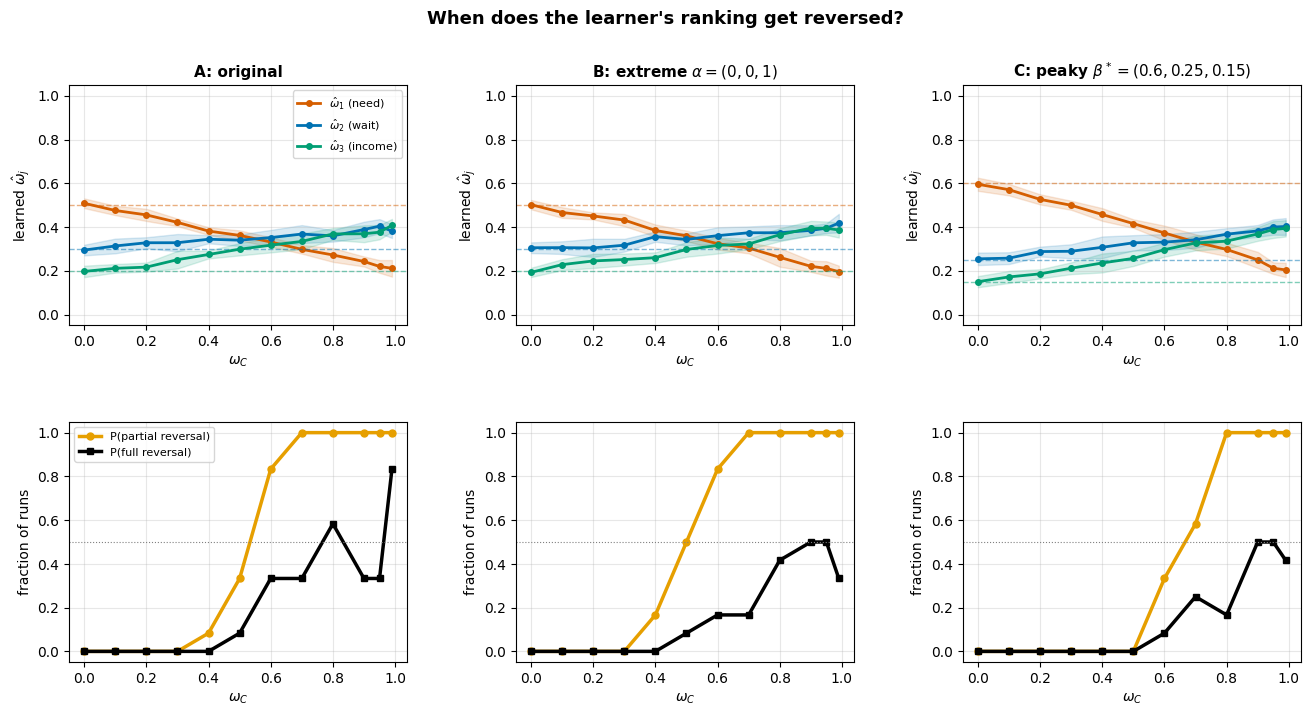

=== Summary ===
  A: original
    first omega_C with P(partial)>0.5: 0.6
    first omega_C with P(full)>0.5:    0.8
    max P(full) over sweep:            0.83
  B: extreme $\alpha=(0,0,1)$
    first omega_C with P(partial)>0.5: 0.6
    first omega_C with P(full)>0.5:    None
    max P(full) over sweep:            0.50
  C: peaky $\beta^*=(0.6,0.25,0.15)$
    first omega_C with P(partial)>0.5: 0.7
    first omega_C with P(full)>0.5:    None
    max P(full) over sweep:            0.50


In [50]:
# Reversal sweep
def reversal_stats(all_o_final, beta_star):
    true_argmax = np.argmax(beta_star)
    true_argmin = np.argmin(beta_star)
    hat_argmax = np.argmax(all_o_final, axis=1)
    return {
        "frac_partial":  float((hat_argmax != true_argmax).mean()),
        "frac_full":     float((hat_argmax == true_argmin).mean()),
        "mean_hat_omega": all_o_final.mean(0),
        "std_hat_omega":  all_o_final.std(0),
    }

OMEGA_VALUES = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99]
SETUPS = [
    ("A: original",
     {"alpha": ALPHA_C_DEFAULT,        "beta_star": BETA_STAR_DEFAULT}),
    (r"B: extreme $\alpha=(0,0,1)$",
     {"alpha": np.array([0.0, 0.0, 1.0]), "beta_star": BETA_STAR_DEFAULT}),
    (r"C: peaky $\beta^*=(0.6,0.25,0.15)$",
     {"alpha": ALPHA_C_DEFAULT,        "beta_star": np.array([0.6, 0.25, 0.15])}),
]

all_stats = {}
for label, cfg in SETUPS:
    print(f"=== {label} ===")
    res = run_sweep(
        omega_C_values=OMEGA_VALUES,
        alpha=cfg["alpha"], beta_star=cfg["beta_star"],
        n_runs=12, n_queries=2000, n_inputs=400,
        base_seed=hash(label) % 10000, verbose=False,
    )
    stats = {}
    for o, (chk, all_o, _) in res.items():
        stats[o] = reversal_stats(all_o[:, -1, :], cfg["beta_star"])
        s = stats[o]
        print(f"  omega_C={o:.2f}: hat_omega={np.round(s['mean_hat_omega'], 3)} "
              f" P(partial)={s['frac_partial']:.2f}  P(full)={s['frac_full']:.2f}")
    all_stats[label] = (stats, cfg["beta_star"])
    print()

# Plot
fig, axes = plt.subplots(2, len(SETUPS), figsize=(5.3 * len(SETUPS), 7.5),
                         gridspec_kw=dict(hspace=0.4, wspace=0.32))
feat_names = [r"$\hat\omega_1$ (need)", r"$\hat\omega_2$ (wait)", r"$\hat\omega_3$ (income)"]

for col, (label, (stats, beta_star)) in enumerate(all_stats.items()):
    omegas = sorted(stats.keys())
    mean_o = np.array([stats[o]["mean_hat_omega"] for o in omegas])
    std_o  = np.array([stats[o]["std_hat_omega"]  for o in omegas])
    p_part = [stats[o]["frac_partial"] for o in omegas]
    p_full = [stats[o]["frac_full"]    for o in omegas]

    ax = axes[0, col]
    for j in range(3):
        ax.plot(omegas, mean_o[:, j], color=FEAT_COLORS[j], lw=2.0, marker='o', ms=4,
                label=feat_names[j])
        ax.fill_between(omegas, mean_o[:, j] - std_o[:, j], mean_o[:, j] + std_o[:, j],
                        color=FEAT_COLORS[j], alpha=0.15)
        ax.axhline(beta_star[j], color=FEAT_COLORS[j], ls='--', lw=1.0, alpha=0.5)
    ax.set_xlabel(r"$\omega_C$"); ax.set_ylabel(r"learned $\hat\omega_j$")
    ax.set_title(label, fontsize=11, fontweight='bold'); ax.set_ylim(-0.05, 1.05)
    ax.grid(alpha=0.3)
    if col == 0:
        ax.legend(fontsize=8, loc='upper right')

    ax2 = axes[1, col]
    ax2.plot(omegas, p_part, color='#E69F00', lw=2.5, marker='o', ms=5,
             label=r"P(partial reversal)")
    ax2.plot(omegas, p_full, color='#000000', lw=2.5, marker='s', ms=5,
             label=r"P(full reversal)")
    ax2.set_xlabel(r"$\omega_C$"); ax2.set_ylabel("fraction of runs")
    ax2.set_ylim(-0.05, 1.05); ax2.grid(alpha=0.3)
    ax2.axhline(0.5, color='gray', ls=':', lw=0.8)
    if col == 0:
        ax2.legend(fontsize=8, loc='upper left')

fig.suptitle("When does the learner's ranking get reversed?",
             y=0.98, fontsize=13, fontweight='bold')
plt.savefig("reversal_experiment.png", dpi=150, bbox_inches='tight')
plt.show()

# Headline summary
print("=== Summary ===")
for label, (stats, _) in all_stats.items():
    first_partial = next((o for o in OMEGA_VALUES if stats[o]["frac_partial"] > 0.5), None)
    first_full    = next((o for o in OMEGA_VALUES if stats[o]["frac_full"]    > 0.5), None)
    max_full      = max(s["frac_full"] for s in stats.values())
    print(f"  {label}")
    print(f"    first omega_C with P(partial)>0.5: {first_partial}")
    print(f"    first omega_C with P(full)>0.5:    {first_full}")
    print(f"    max P(full) over sweep:            {max_full:.2f}")


## 7. Reliable full reversal: aim the inseparable frame at the income axis

§6 showed full reversal happens only ~58% of the time at $\omega_C \to 1$ — it's borderline. The need-axis inseparable frame *deflates* $\hat\omega_1$, but the displaced mass redistributes roughly proportionally to $\beta^*$ between $\hat\omega_2$ and $\hat\omega_3$. Reversal happens only when sampling noise tips the redistribution toward $\hat\omega_3$.

To make full reversal *reliable*, point an inseparable frame directly at $\delta_3$ (income).

**Construction.** Use a continuous-mean inseparable utility:
$$u_\text{inc}(F) = -n \cdot (\overline{\psi_3}(F) - \tau)^2, \quad \tau = 0.9$$
The $n$ scaling makes the per-query local gap $O(1)$ instead of $O(1/n)$ — comparable to the separable signal. The local gap is then linear in $\delta_3(x) = \psi_3(x, y=1) - \psi_3(x, y=0)$, so the inseparable signal correlates *perfectly* with the income axis. The MLE absorbs this directly into $\hat\omega_3$.

(Without the $n$-scaling, the inseparable signal has magnitude $\sim 0.001$ per query — much smaller than the separable signal $\sim 0.1$. With $n$-scaling, it's $\sim 0.27$, in the same ballpark.)


=== Pure income frame (scaled, target=0.9) ===
  omega_inc=0.1: hat_omega=[0.46  0.267 0.273]  P(partial)=0.00  P(full)=0.00
  omega_inc=0.2: hat_omega=[0.401 0.262 0.337]  P(partial)=0.07  P(full)=0.07
  omega_inc=0.3: hat_omega=[0.365 0.211 0.424]  P(partial)=0.87  P(full)=0.87
  omega_inc=0.5: hat_omega=[0.271 0.173 0.556]  P(partial)=1.00  P(full)=1.00
  omega_inc=0.7: hat_omega=[0.174 0.12  0.705]  P(partial)=1.00  P(full)=1.00

=== Combined need + income ===
  only need ω_n=0.4: hat_omega=[0.399 0.332 0.269]  P(partial)=0.07  P(full)=0.00
  ω_n=0.3, ω_i=0.2: hat_omega=[0.325 0.283 0.391]  P(partial)=0.93  P(full)=0.93
  ω_n=0.2, ω_i=0.3: hat_omega=[0.308 0.241 0.451]  P(partial)=1.00  P(full)=1.00
  ω_n=0.1, ω_i=0.4: hat_omega=[0.29  0.192 0.517]  P(partial)=1.00  P(full)=1.00
  only income ω_i=0.5: hat_omega=[0.259 0.168 0.572]  P(partial)=1.00  P(full)=1.00


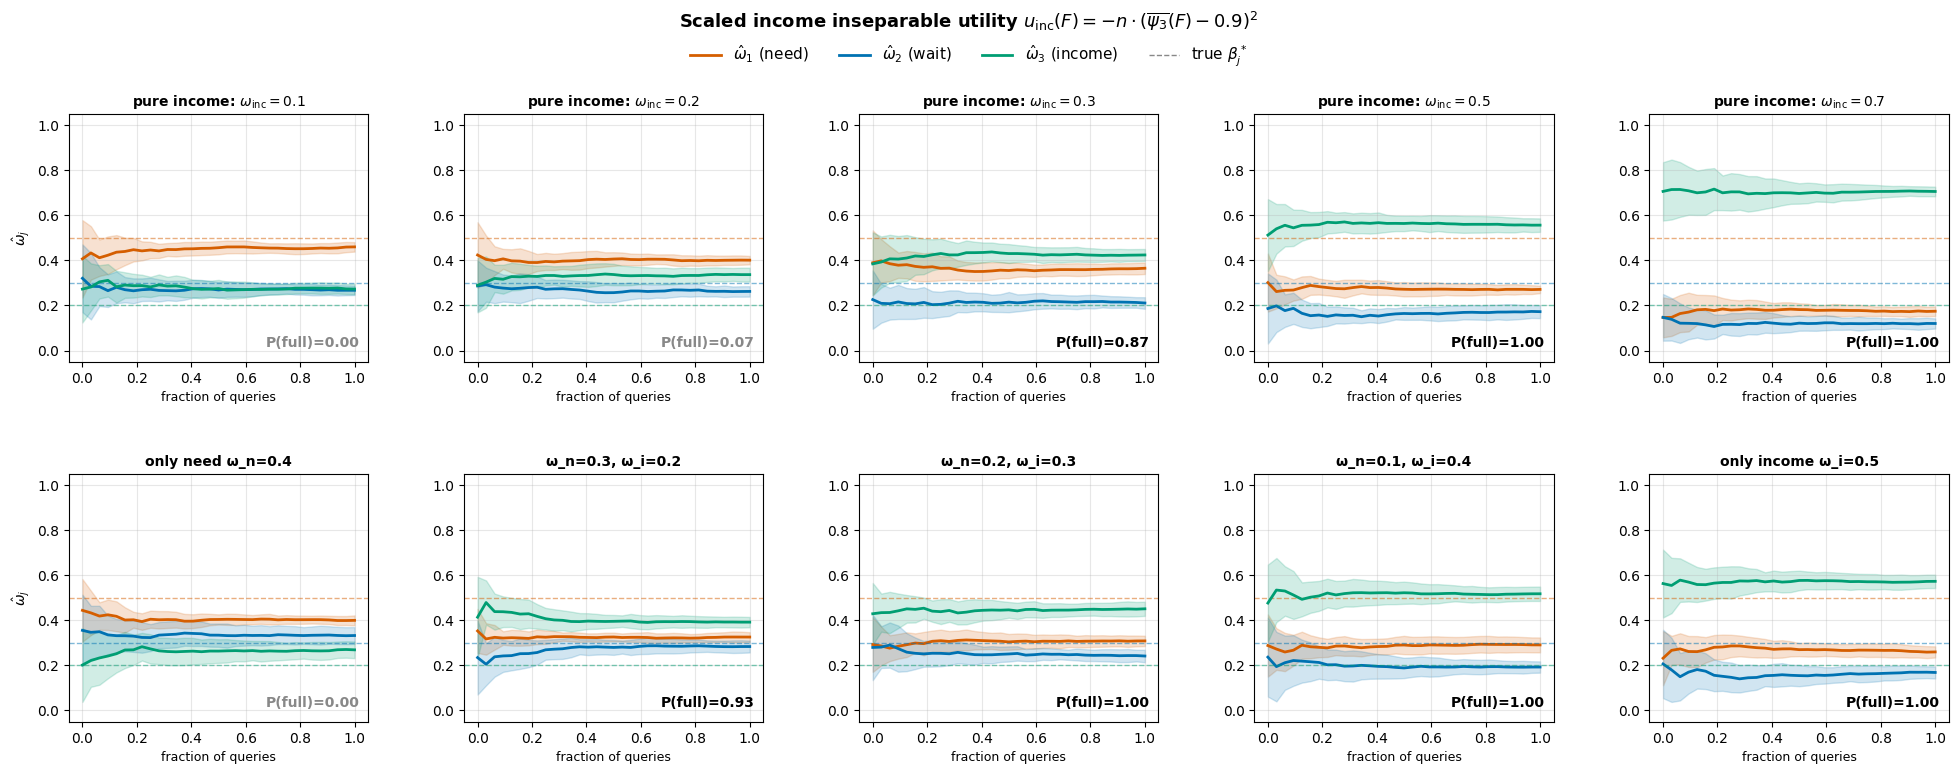

In [51]:
# Reliable full reversal via an income-axis inseparable frame
def compute_s_mean_income(psi, target_mean, rng, n_bg=1500, feat_idx=2, strength=None):
    """
    u_inc(F) = -strength * (mean(psi_{feat_idx}, F) - target)^2.
    Scaling by strength=n_inputs gives the per-query gap O(1).
    """
    n_inputs = psi.shape[0]
    if strength is None:
        strength = n_inputs
    feat = psi[:, :, feat_idx]
    bg = rng.integers(0, 2, size=(n_bg, n_inputs))
    x_idx = np.arange(n_inputs)[None, :]
    chosen_v = feat[x_idx, bg]
    mean_F = chosen_v.mean(axis=1)
    f_y0 = feat[:, 0]; f_y1 = feat[:, 1]
    sp = np.zeros(n_inputs); sm = np.zeros(n_inputs)
    inv_n = 1.0 / n_inputs
    for x in range(n_inputs):
        f_curr = chosen_v[:, x]
        m_to_1 = mean_F + (f_y1[x] - f_curr) * inv_n
        m_to_0 = mean_F + (f_y0[x] - f_curr) * inv_n
        d = strength * (-(m_to_1 - target_mean) ** 2 + (m_to_0 - target_mean) ** 2)
        sp[x] = max(d.max(), 0.0)
        sm[x] = max((-d).max(), 0.0)
    return sp, sm


def run_one_two_frames(omega_need, alpha_need, omega_inc, target_inc,
                       n_queries, n_inputs, seed,
                       beta_star=BETA_STAR_DEFAULT, noise_scale=LOGISTIC_SCALE_DEFAULT,
                       query_batch=60):
    rng = np.random.default_rng(seed)
    D = len(beta_star)
    psi_raw = sample_psi_raw(rng, n_inputs, D)
    psi = recode_psi(psi_raw)
    contribs = []
    if omega_need > 0:
        sp_n, sm_n = compute_s_C(psi_raw, alpha_need, rng)
        contribs.append((omega_need, sp_n, sm_n))
    if omega_inc > 0:
        sp_i, sm_i = compute_s_mean_income(psi, target_inc, rng)
        contribs.append((omega_inc, sp_i, sm_i))
    total = omega_need + omega_inc
    omega_sep = beta_star * (1 - total)
    xs = rng.integers(0, n_inputs, size=n_queries)
    resp = generate_responses(psi, xs, omega_sep, contribs, rng, noise_scale)
    deltas = sep_gap(psi)[xs]
    chk = list(range(query_batch, n_queries + 1, query_batch))
    traj = np.zeros((len(chk), D))
    for ci, cp in enumerate(chk):
        traj[ci] = fit_score_rum(deltas[:cp], resp[:cp], noise_scale)
    return chk, traj


# Sweep: pure income frame at growing weights
print("=== Pure income frame (scaled, target=0.9) ===")
N_RUNS = 15; N_QUERIES = 2000; N_INPUTS = 400; TARGET = 0.9
pure_results = {}
for omega_inc in [0.1, 0.2, 0.3, 0.5, 0.7]:
    trajs = []
    for r in range(N_RUNS):
        seed = 1111 + r * 17 + int(omega_inc * 10000)
        chk, t = run_one_two_frames(0.0, ALPHA_C_DEFAULT, omega_inc, TARGET,
                                    N_QUERIES, N_INPUTS, seed)
        trajs.append(t)
    trajs = np.array(trajs); final = trajs[:, -1, :]
    mean_final = final.mean(0)
    p_part = (np.argmax(final, axis=1) != 0).mean()
    p_full = (np.argmax(final, axis=1) == 2).mean()
    print(f"  omega_inc={omega_inc}: hat_omega={np.round(mean_final, 3)}  "
          f"P(partial)={p_part:.2f}  P(full)={p_full:.2f}")
    pure_results[omega_inc] = (chk, trajs, mean_final, p_part, p_full)


# Sweep: combined need + income
print("\n=== Combined need + income ===")
combo = [("only need ω_n=0.4", 0.4, 0.0),
         ("ω_n=0.3, ω_i=0.2",   0.3, 0.2),
         ("ω_n=0.2, ω_i=0.3",   0.2, 0.3),
         ("ω_n=0.1, ω_i=0.4",   0.1, 0.4),
         ("only income ω_i=0.5", 0.0, 0.5)]
combo_results = {}
for label, on, oi in combo:
    trajs = []
    for r in range(N_RUNS):
        seed = 2222 + r * 19 + int(on * 100) + int(oi * 1000)
        chk, t = run_one_two_frames(on, ALPHA_C_DEFAULT, oi, TARGET,
                                    N_QUERIES, N_INPUTS, seed)
        trajs.append(t)
    trajs = np.array(trajs); final = trajs[:, -1, :]
    mean_final = final.mean(0)
    p_part = (np.argmax(final, axis=1) != 0).mean()
    p_full = (np.argmax(final, axis=1) == 2).mean()
    print(f"  {label}: hat_omega={np.round(mean_final, 3)}  "
          f"P(partial)={p_part:.2f}  P(full)={p_full:.2f}")
    combo_results[label] = (chk, trajs, mean_final, p_part, p_full)


# Plot
fig = plt.figure(figsize=(20, 8))
gs = fig.add_gridspec(2, 5, hspace=0.45, wspace=0.32,
                      left=0.05, right=0.99, top=0.86, bottom=0.10)
FEAT_NAMES_FULL = [r"$\hat\omega_1$ (need)", r"$\hat\omega_2$ (wait)", r"$\hat\omega_3$ (income)"]

for col, (oi, (chk, trajs, mf, pp, pf)) in enumerate(pure_results.items()):
    ax = fig.add_subplot(gs[0, col])
    mt = trajs.mean(0); st = trajs.std(0)
    xs_plt = np.arange(len(chk)) / (len(chk) - 1)
    for j in range(3):
        ax.plot(xs_plt, mt[:, j], color=FEAT_COLORS[j], lw=2.0)
        ax.fill_between(xs_plt, mt[:, j] - st[:, j], mt[:, j] + st[:, j],
                        color=FEAT_COLORS[j], alpha=0.18)
        ax.axhline(BETA_STAR_DEFAULT[j], color=FEAT_COLORS[j], ls='--', lw=1.0, alpha=0.5)
    ax.set_ylim(-0.05, 1.05); ax.grid(alpha=0.3)
    ax.set_title(rf"pure income: $\omega_\text{{inc}}={oi}$", fontsize=10, fontweight='bold')
    ax.set_xlabel("fraction of queries", fontsize=9)
    if col == 0: ax.set_ylabel(r"$\hat\omega_j$", fontsize=10)
    ax.annotate(f"P(full)={pf:.2f}", xy=(0.97, 0.05), xycoords='axes fraction',
                ha='right', va='bottom', fontsize=10,
                color='#000000' if pf > 0.5 else '#888', fontweight='bold')

for col, (label, (chk, trajs, mf, pp, pf)) in enumerate(combo_results.items()):
    ax = fig.add_subplot(gs[1, col])
    mt = trajs.mean(0); st = trajs.std(0)
    xs_plt = np.arange(len(chk)) / (len(chk) - 1)
    for j in range(3):
        ax.plot(xs_plt, mt[:, j], color=FEAT_COLORS[j], lw=2.0)
        ax.fill_between(xs_plt, mt[:, j] - st[:, j], mt[:, j] + st[:, j],
                        color=FEAT_COLORS[j], alpha=0.18)
        ax.axhline(BETA_STAR_DEFAULT[j], color=FEAT_COLORS[j], ls='--', lw=1.0, alpha=0.5)
    ax.set_ylim(-0.05, 1.05); ax.grid(alpha=0.3)
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_xlabel("fraction of queries", fontsize=9)
    if col == 0: ax.set_ylabel(r"$\hat\omega_j$", fontsize=10)
    ax.annotate(f"P(full)={pf:.2f}", xy=(0.97, 0.05), xycoords='axes fraction',
                ha='right', va='bottom', fontsize=10,
                color='#000000' if pf > 0.5 else '#888', fontweight='bold')

from matplotlib.lines import Line2D
handles = [Line2D([0], [0], color=FEAT_COLORS[j], lw=2.0, label=FEAT_NAMES_FULL[j])
           for j in range(3)]
handles.append(Line2D([0], [0], color='#888', lw=1.0, ls='--', label=r'true $\beta^*_j$'))
fig.legend(handles=handles, loc='upper center', ncol=4, fontsize=11,
           frameon=False, bbox_to_anchor=(0.5, 0.965))
fig.suptitle(r"Scaled income inseparable utility $u_\text{inc}(F) = -n \cdot (\overline{\psi_3}(F) - 0.9)^2$",
             y=0.99, fontsize=13, fontweight='bold')
plt.savefig("reversal_income_scaled.png", dpi=150, bbox_inches='tight')
plt.show()


## 8. Head-to-head: original vs scaled-income utility, $\omega_C \in [0, 0.99]$

Direct apples-to-apples comparison of the two utilities, sweeping $\omega_C$ over the full range. The original utility ($u_C = -\sum_g (p_g - \alpha_g)^2$) and the scaled-income utility ($u_\text{inc} = -n(\overline{\psi_3} - 0.9)^2$) confound the learner *very* differently:

- **Original** correlates with $\delta_1$ at $-0.99$ and has $O(1/n)$ signal magnitude → *deflates* $\hat\omega_1$; mass redistributes noisily between $\hat\omega_2, \hat\omega_3$.
- **Scaled income** correlates with $\delta_3$ at $+1.0$ and has $O(1)$ signal magnitude → *directly inflates* $\hat\omega_3$.

The plot shows (top row) the mean final $\hat\omega$ trajectories per utility and (bottom row) the probabilities of partial vs full reversal across the $\omega_C$ sweep.



=== need_original ===
  omega_C=0.00: hat_omega=[0.504 0.304 0.192]  P(partial)=0.00  P(full)=0.00
  omega_C=0.10: hat_omega=[0.479 0.302 0.219]  P(partial)=0.00  P(full)=0.00
  omega_C=0.20: hat_omega=[0.452 0.32  0.227]  P(partial)=0.00  P(full)=0.00
  omega_C=0.30: hat_omega=[0.421 0.336 0.243]  P(partial)=0.08  P(full)=0.00
  omega_C=0.40: hat_omega=[0.394 0.323 0.283]  P(partial)=0.17  P(full)=0.08
  omega_C=0.50: hat_omega=[0.354 0.329 0.317]  P(partial)=0.33  P(full)=0.25
  omega_C=0.60: hat_omega=[0.35  0.347 0.303]  P(partial)=0.42  P(full)=0.00
  omega_C=0.70: hat_omega=[0.306 0.373 0.321]  P(partial)=1.00  P(full)=0.33
  omega_C=0.80: hat_omega=[0.271 0.355 0.375]  P(partial)=1.00  P(full)=0.67
  omega_C=0.90: hat_omega=[0.237 0.384 0.378]  P(partial)=1.00  P(full)=0.42
  omega_C=0.95: hat_omega=[0.22  0.386 0.393]  P(partial)=1.00  P(full)=0.67
  omega_C=0.99: hat_omega=[0.208 0.38  0.412]  P(partial)=1.00  P(full)=0.67

=== income_scaled ===
  omega_C=0.00: hat_omega=[0.5

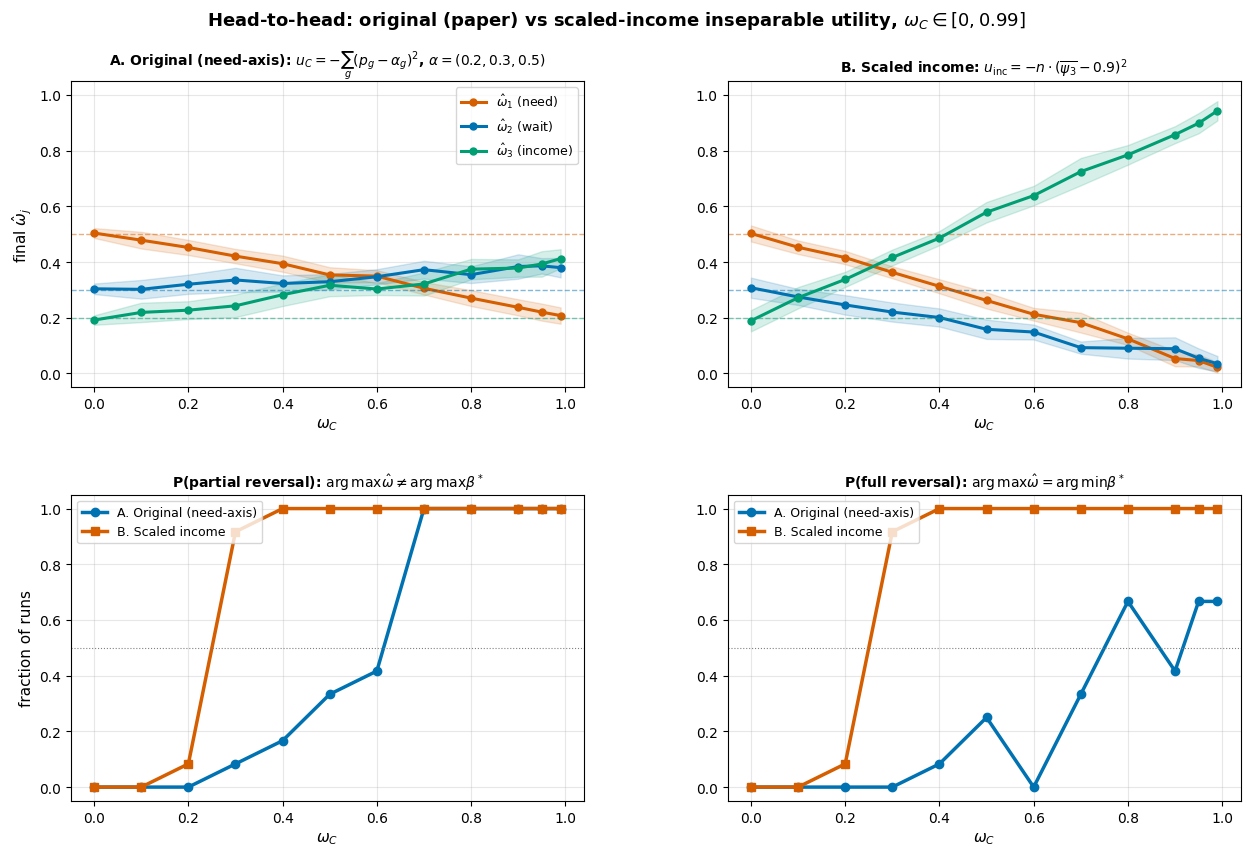


=== Summary ===

need_original:
  first omega_C with P(partial)>0.5: 0.7
  first omega_C with P(full)>0.5:    0.8
  max P(full):                       0.67
  hat_omega at omega_C=0.99:         [0.208 0.38  0.412]

income_scaled:
  first omega_C with P(partial)>0.5: 0.3
  first omega_C with P(full)>0.5:    0.3
  max P(full):                       1.00
  hat_omega at omega_C=0.99:         [0.022 0.035 0.943]


In [52]:
# Head-to-head sweep: original (paper) vs scaled-income utility
N_RUNS    = 12
N_QUERIES = 1500
N_INPUTS  = 400
QUERY_BATCH = 100
OMEGA_VALUES = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99]


def run_one_compare(utility, omega_C, n_queries, n_inputs, seed,
                    beta_star=BETA_STAR_DEFAULT,
                    noise_scale=LOGISTIC_SCALE_DEFAULT, query_batch=QUERY_BATCH):
    rng = np.random.default_rng(seed)
    D = len(beta_star)
    psi_raw = sample_psi_raw(rng, n_inputs, D)
    psi = recode_psi(psi_raw)
    if utility == "need_original":
        sp, sm = compute_s_C(psi_raw, ALPHA_C_DEFAULT, rng)
    elif utility == "income_scaled":
        # compute_s_mean_income was defined in §7 — reuse it
        sp, sm = compute_s_mean_income(psi, 0.9, rng)
    else:
        raise ValueError(utility)
    omega_sep = beta_star * (1 - omega_C)
    xs = rng.integers(0, n_inputs, size=n_queries)
    resp = generate_responses(psi, xs, omega_sep, [(omega_C, sp, sm)], rng, noise_scale)
    deltas = sep_gap(psi)[xs]
    chk = list(range(query_batch, n_queries + 1, query_batch))
    traj = np.zeros((len(chk), D))
    for ci, cp in enumerate(chk):
        traj[ci] = fit_score_rum(deltas[:cp], resp[:cp], noise_scale)
    return chk, traj


results = {}
for utility in ("need_original", "income_scaled"):
    print(f"\n=== {utility} ===")
    results[utility] = {}
    for o in OMEGA_VALUES:
        trajs = []
        for r in range(N_RUNS):
            seed = (hash(utility) % 10000) + r * 17 + int(o * 10000)
            chk, t = run_one_compare(utility, o, N_QUERIES, N_INPUTS, seed)
            trajs.append(t)
        trajs = np.array(trajs)
        final = trajs[:, -1, :]
        mean_final = final.mean(0); std_final = final.std(0)
        p_part = float((np.argmax(final, axis=1) != 0).mean())
        p_full = float((np.argmax(final, axis=1) == 2).mean())
        print(f"  omega_C={o:.2f}: hat_omega={np.round(mean_final, 3)}  "
              f"P(partial)={p_part:.2f}  P(full)={p_full:.2f}")
        results[utility][o] = {
            "mean_final": mean_final, "std_final": std_final,
            "p_partial": p_part, "p_full": p_full,
        }


# Plot
FEAT_NAMES_FULL = [r"$\hat\omega_1$ (need)", r"$\hat\omega_2$ (wait)", r"$\hat\omega_3$ (income)"]
UTIL_LABELS = {
    "need_original":  r"A. Original (need-axis): $u_C = -\sum_g (p_g - \alpha_g)^2$, $\alpha=(0.2,0.3,0.5)$",
    "income_scaled":  r"B. Scaled income: $u_\text{inc} = -n \cdot (\overline{\psi_3} - 0.9)^2$",
}

fig = plt.figure(figsize=(13, 9))
gs = fig.add_gridspec(2, 2, hspace=0.35, wspace=0.28,
                      left=0.08, right=0.98, top=0.88, bottom=0.08)

for col, util in enumerate(("need_original", "income_scaled")):
    ax = fig.add_subplot(gs[0, col])
    means = np.array([results[util][o]["mean_final"] for o in OMEGA_VALUES])
    stds  = np.array([results[util][o]["std_final"]  for o in OMEGA_VALUES])
    for j in range(3):
        ax.plot(OMEGA_VALUES, means[:, j], color=FEAT_COLORS[j],
                lw=2.2, marker='o', ms=5, label=FEAT_NAMES_FULL[j])
        ax.fill_between(OMEGA_VALUES,
                        means[:, j] - stds[:, j], means[:, j] + stds[:, j],
                        color=FEAT_COLORS[j], alpha=0.16)
        ax.axhline(BETA_STAR_DEFAULT[j], color=FEAT_COLORS[j], ls='--', lw=1.0, alpha=0.5)
    ax.set_title(UTIL_LABELS[util], fontsize=10, fontweight='bold')
    ax.set_xlabel(r"$\omega_C$", fontsize=11)
    if col == 0:
        ax.set_ylabel(r"final $\hat\omega_j$", fontsize=11)
    ax.set_ylim(-0.05, 1.05); ax.grid(alpha=0.3)
    if col == 0:
        ax.legend(fontsize=9, loc='upper right')

for col, kind in enumerate(("p_partial", "p_full")):
    ax = fig.add_subplot(gs[1, col])
    for util, marker, color in [("need_original", "o", "#0072B2"),
                                 ("income_scaled", "s", "#D55E00")]:
        ps = [results[util][o][kind] for o in OMEGA_VALUES]
        ax.plot(OMEGA_VALUES, ps, color=color, lw=2.5, marker=marker, ms=6,
                label=UTIL_LABELS[util].split(":")[0])
    ax.set_xlabel(r"$\omega_C$", fontsize=11)
    if col == 0:
        ax.set_ylabel("fraction of runs", fontsize=11)
    title = ("P(partial reversal): " + r"$\arg\max\hat\omega \neq \arg\max\beta^*$"
             if kind == "p_partial"
             else "P(full reversal): " + r"$\arg\max\hat\omega = \arg\min\beta^*$")
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_ylim(-0.05, 1.05)
    ax.axhline(0.5, color='gray', ls=':', lw=0.8)
    ax.grid(alpha=0.3); ax.legend(fontsize=9, loc='upper left')

fig.suptitle(r"Head-to-head: original (paper) vs scaled-income inseparable utility, $\omega_C \in [0, 0.99]$",
             y=0.96, fontsize=13, fontweight='bold')
plt.savefig("utility_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

# Summary
print("\n=== Summary ===")
for util in ("need_original", "income_scaled"):
    s = results[util]
    first_part = next((o for o in OMEGA_VALUES if s[o]["p_partial"] > 0.5), None)
    first_full = next((o for o in OMEGA_VALUES if s[o]["p_full"]    > 0.5), None)
    max_full   = max(s[o]["p_full"] for o in OMEGA_VALUES)
    print(f"\n{util}:")
    print(f"  first omega_C with P(partial)>0.5: {first_part}")
    print(f"  first omega_C with P(full)>0.5:    {first_full}")
    print(f"  max P(full):                       {max_full:.2f}")
    print(f"  hat_omega at omega_C=0.99:         {np.round(s[0.99]['mean_final'], 3)}")


## Per-utility sweeps: $\hat\omega$ trajectories and $\ell_1$ error

Two paper-compliant inseparable utilities, swept independently. Each gets its own figure showing **(left)** the final learned weights $\hat\omega_j$ as a function of the inseparable weight, and **(right)** the $\ell_1$ error $\|\hat\omega - \beta^*\|_1$.

- **Figure A** — proportionality priority $u_C = -\sum_g (p_g^F - \alpha_g)^2$, $\alpha = (0.2, 0.3, 0.5)$.
- **Figure B** — income soft-floor priority $u_\text{floor} = -(\eta - \overline{\psi_3}(F))_+^2$, $\eta = 0.7$.

Both satisfy $|u(F) - u(F')| \le 1$ and produce per-query signals of $O(1/n)$.


=== Sweep u_C alone ===
  x=0.00: ω_C=0.000, ω_f=0.000


  x=0.10: ω_C=0.100, ω_f=0.000
  x=0.20: ω_C=0.200, ω_f=0.000
  x=0.30: ω_C=0.300, ω_f=0.000
  x=0.40: ω_C=0.400, ω_f=0.000
  x=0.50: ω_C=0.500, ω_f=0.000
  x=0.60: ω_C=0.600, ω_f=0.000
  x=0.70: ω_C=0.700, ω_f=0.000
  x=0.80: ω_C=0.800, ω_f=0.000
  x=0.90: ω_C=0.900, ω_f=0.000
  x=0.95: ω_C=0.950, ω_f=0.000
  x=0.99: ω_C=0.990, ω_f=0.000

=== Sweep u_floor alone ===
  x=0.00: ω_C=0.000, ω_f=0.000
  x=0.10: ω_C=0.000, ω_f=0.100
  x=0.20: ω_C=0.000, ω_f=0.200
  x=0.30: ω_C=0.000, ω_f=0.300
  x=0.40: ω_C=0.000, ω_f=0.400
  x=0.50: ω_C=0.000, ω_f=0.500
  x=0.60: ω_C=0.000, ω_f=0.600
  x=0.70: ω_C=0.000, ω_f=0.700
  x=0.80: ω_C=0.000, ω_f=0.800
  x=0.90: ω_C=0.000, ω_f=0.900
  x=0.95: ω_C=0.000, ω_f=0.950
  x=0.99: ω_C=0.000, ω_f=0.990


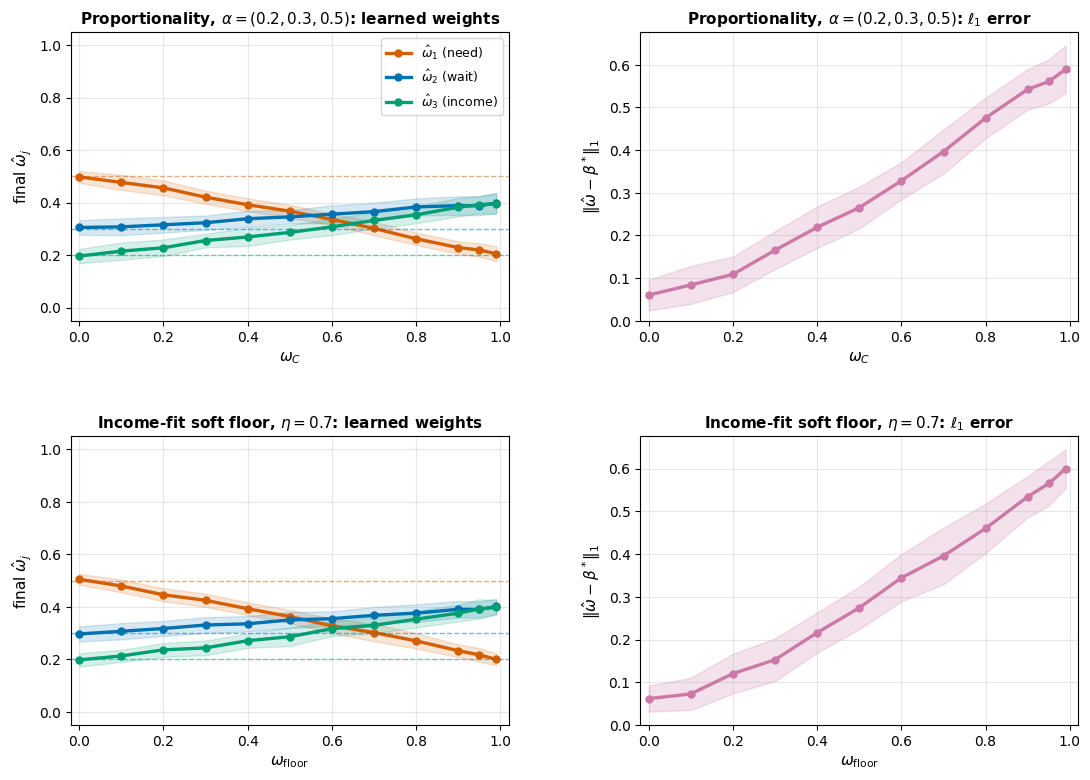


=== Summary ===

u_C:
  x=0.00: hat_omega=[0.498 0.305 0.197]  L1=0.060
  x=0.10: hat_omega=[0.477 0.308 0.215]  L1=0.084
  x=0.20: hat_omega=[0.456 0.316 0.228]  L1=0.109
  x=0.30: hat_omega=[0.421 0.324 0.256]  L1=0.165
  x=0.40: hat_omega=[0.392 0.339 0.269]  L1=0.219
  x=0.50: hat_omega=[0.367 0.346 0.287]  L1=0.265
  x=0.60: hat_omega=[0.336 0.356 0.308]  L1=0.328
  x=0.70: hat_omega=[0.302 0.366 0.332]  L1=0.397
  x=0.80: hat_omega=[0.262 0.384 0.354]  L1=0.475
  x=0.90: hat_omega=[0.229 0.389 0.383]  L1=0.543
  x=0.95: hat_omega=[0.22  0.388 0.392]  L1=0.561
  x=0.99: hat_omega=[0.205 0.398 0.396]  L1=0.589

u_floor:
  x=0.00: hat_omega=[0.505 0.297 0.198]  L1=0.062
  x=0.10: hat_omega=[0.48  0.307 0.213]  L1=0.073
  x=0.20: hat_omega=[0.446 0.318 0.236]  L1=0.120
  x=0.30: hat_omega=[0.425 0.331 0.244]  L1=0.153
  x=0.40: hat_omega=[0.393 0.336 0.271]  L1=0.216
  x=0.50: hat_omega=[0.363 0.35  0.286]  L1=0.274
  x=0.60: hat_omega=[0.328 0.355 0.317]  L1=0.345
  x=0.70: hat_ome

In [56]:
# Per-utility sweeps: trajectories AND L1 error
def compute_s_income_floor(psi, eta, rng, n_bg=1500, feat_idx=2):
    """Paper-compliant soft floor on average income fit:
       u_floor(F) = -(eta - mean(psi_feat))_+^2.   |u(F)-u(F')| ≤ eta² ≤ 1."""
    n_inputs = psi.shape[0]
    feat = psi[:, :, feat_idx]
    bg = rng.integers(0, 2, size=(n_bg, n_inputs))
    x_idx = np.arange(n_inputs)[None, :]
    chosen_v = feat[x_idx, bg]
    mean_F = chosen_v.mean(axis=1)
    f_y0, f_y1 = feat[:, 0], feat[:, 1]
    sp = np.zeros(n_inputs); sm = np.zeros(n_inputs)
    inv_n = 1.0 / n_inputs
    for x in range(n_inputs):
        f_curr = chosen_v[:, x]
        m_to_1 = mean_F + (f_y1[x] - f_curr) * inv_n
        m_to_0 = mean_F + (f_y0[x] - f_curr) * inv_n
        d = -np.maximum(eta - m_to_1, 0) ** 2 + np.maximum(eta - m_to_0, 0) ** 2
        sp[x] = max(d.max(), 0.0)
        sm[x] = max((-d).max(), 0.0)
    return sp, sm


def _run_one_metric(omega_C, omega_floor, n_queries, n_inputs, seed,
                     alpha=None, eta=0.7):
    if alpha is None:
        alpha = ALPHA_C_DEFAULT
    rng = np.random.default_rng(seed)
    psi_raw = sample_psi_raw(rng, n_inputs, 3)
    psi = recode_psi(psi_raw)
    contribs = []
    if omega_C > 0:
        sp_n, sm_n = compute_s_C(psi_raw, alpha, rng)
        contribs.append((omega_C, sp_n, sm_n))
    if omega_floor > 0:
        sp_f, sm_f = compute_s_income_floor(psi, eta, rng)
        contribs.append((omega_floor, sp_f, sm_f))
    total = omega_C + omega_floor
    omega_sep = BETA_STAR_DEFAULT * (1 - total)
    xs = rng.integers(0, n_inputs, size=n_queries)
    resp = generate_responses(psi, xs, omega_sep, contribs, rng, LOGISTIC_SCALE_DEFAULT)
    deltas = sep_gap(psi)[xs]
    return fit_score_rum(deltas, resp, LOGISTIC_SCALE_DEFAULT)


N_RUNS = 60; N_QUERIES = 2000; N_INPUTS = 800
X_VALUES = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99]


def _sweep_metric(omega_C_fn, omega_floor_fn, seed_base):
    """Returns (means, stds, l1_means, l1_stds) over x_values."""
    finals_per_x = []
    for x in X_VALUES:
        omega_C = omega_C_fn(x); omega_f = omega_floor_fn(x)
        print(f"  x={x:.2f}: ω_C={omega_C:.3f}, ω_f={omega_f:.3f}", flush=True)
        finals = []
        for r in range(N_RUNS):
            seed = seed_base + r * 17 + int(x * 10000)
            finals.append(_run_one_metric(omega_C, omega_f, N_QUERIES, N_INPUTS, seed))
        finals_per_x.append(np.array(finals))
    means = np.array([f.mean(0) for f in finals_per_x])
    stds  = np.array([f.std(0)  for f in finals_per_x])
    l1    = np.array([np.abs(f - BETA_STAR_DEFAULT[None, :]).sum(axis=1) for f in finals_per_x])
    return means, stds, l1.mean(axis=1), l1.std(axis=1)


print("=== Sweep u_C alone ===")
uC_mean, uC_std, uC_l1m, uC_l1s = _sweep_metric(lambda x: x, lambda x: 0.0, 10000)
print("\n=== Sweep u_floor alone ===")
uF_mean, uF_std, uF_l1m, uF_l1s = _sweep_metric(lambda x: 0.0, lambda x: x, 20000)


FEAT_NAMES_M = [r"$\hat\omega_1$ (need)", r"$\hat\omega_2$ (wait)", r"$\hat\omega_3$ (income)"]


def _draw_utility_row(axes_row, mean, std, l1m, l1s, util_label, xlabel, show_legend=False):
    """Draw a single utility's (trajectory, L1 error) pair into two axes."""
    ax = axes_row[0]
    for j in range(3):
        ax.plot(X_VALUES, mean[:, j], color=FEAT_COLORS[j], lw=2.4,
                marker='o', ms=5, label=FEAT_NAMES_M[j])
        ax.fill_between(X_VALUES,
                        mean[:, j] - std[:, j], mean[:, j] + std[:, j],
                        color=FEAT_COLORS[j], alpha=0.16)
        ax.axhline(BETA_STAR_DEFAULT[j], color=FEAT_COLORS[j], ls='--', lw=1.0, alpha=0.5)
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(r"final $\hat\omega_j$", fontsize=11)
    ax.set_ylim(-0.05, 1.05); ax.set_xlim(-0.02, 1.02)
    ax.grid(alpha=0.3)
    if show_legend:
        ax.legend(fontsize=9, loc='upper right')
    ax.set_title(rf"{util_label}: learned weights", fontsize=11, fontweight='bold')

    ax2 = axes_row[1]
    ax2.plot(X_VALUES, l1m, color='#CC79A7', lw=2.4, marker='o', ms=5)
    ax2.fill_between(X_VALUES,
                     np.maximum(l1m - l1s, 0), l1m + l1s,
                     color='#CC79A7', alpha=0.22)
    ax2.set_xlabel(xlabel, fontsize=11)
    ax2.set_ylabel(r"$\|\hat\omega - \beta^*\|_1$", fontsize=11)
    ax2.set_xlim(-0.02, 1.02); ax2.set_ylim(0, None)
    ax2.grid(alpha=0.3)
    ax2.set_title(rf"{util_label}: $\ell_1$ error", fontsize=11, fontweight='bold')


fig, axes = plt.subplots(2, 2, figsize=(13, 9),
                          gridspec_kw=dict(wspace=0.30, hspace=0.40))
_draw_utility_row(
    axes[0], uC_mean, uC_std, uC_l1m, uC_l1s,
    util_label=r"Proportionality, $\alpha=(0.2,0.3,0.5)$",
    xlabel=r"$\omega_C$",
    show_legend=True,
)
_draw_utility_row(
    axes[1], uF_mean, uF_std, uF_l1m, uF_l1s,
    util_label=r"Income-fit soft floor, $\eta=0.7$",
    xlabel=r"$\omega_\text{floor}$",
    show_legend=False,
)
plt.savefig("uC_uFloor_sweep.png", dpi=150, bbox_inches='tight')
plt.show()


print("\n=== Summary ===")
for name, mean, l1m in [(r"u_C", uC_mean, uC_l1m), (r"u_floor", uF_mean, uF_l1m)]:
    print(f"\n{name}:")
    for i, x in enumerate(X_VALUES):
        print(f"  x={x:.2f}: hat_omega={np.round(mean[i], 3)}  L1={l1m[i]:.3f}")


## Convergence over queries (at fixed inseparable weight)

To show that the confounded $\hat\omega$ is a **stable MLE limit** — not just sampling noise — we hold the inseparable weight fixed and plot $\hat\omega_t$ as a function of the number of queries $t$, across many independent trials. If the trajectories converge to a tight band, the corruption is systematic; if they wander, it's noise.

Two figures, one per utility, at $\omega = 0.7$ (in the visible-confounding regime, well below the noise-dominated extreme).


=== Convergence at ω=0.7, N_RUNS=60, T=10000 ===
u_C trajectories...
u_floor trajectories...

=== Sanity check at ω=0.0, N_RUNS=60, T=10000 ===
u_C (off) trajectories...
u_floor (off) trajectories...


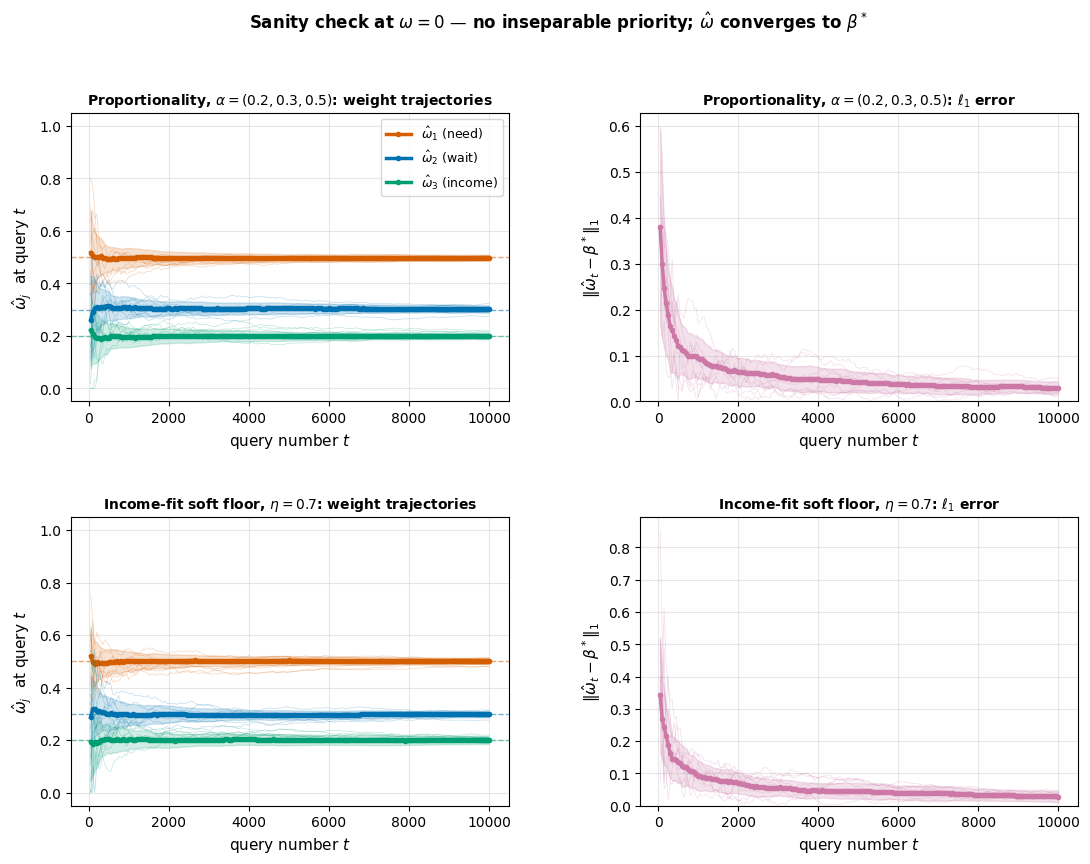

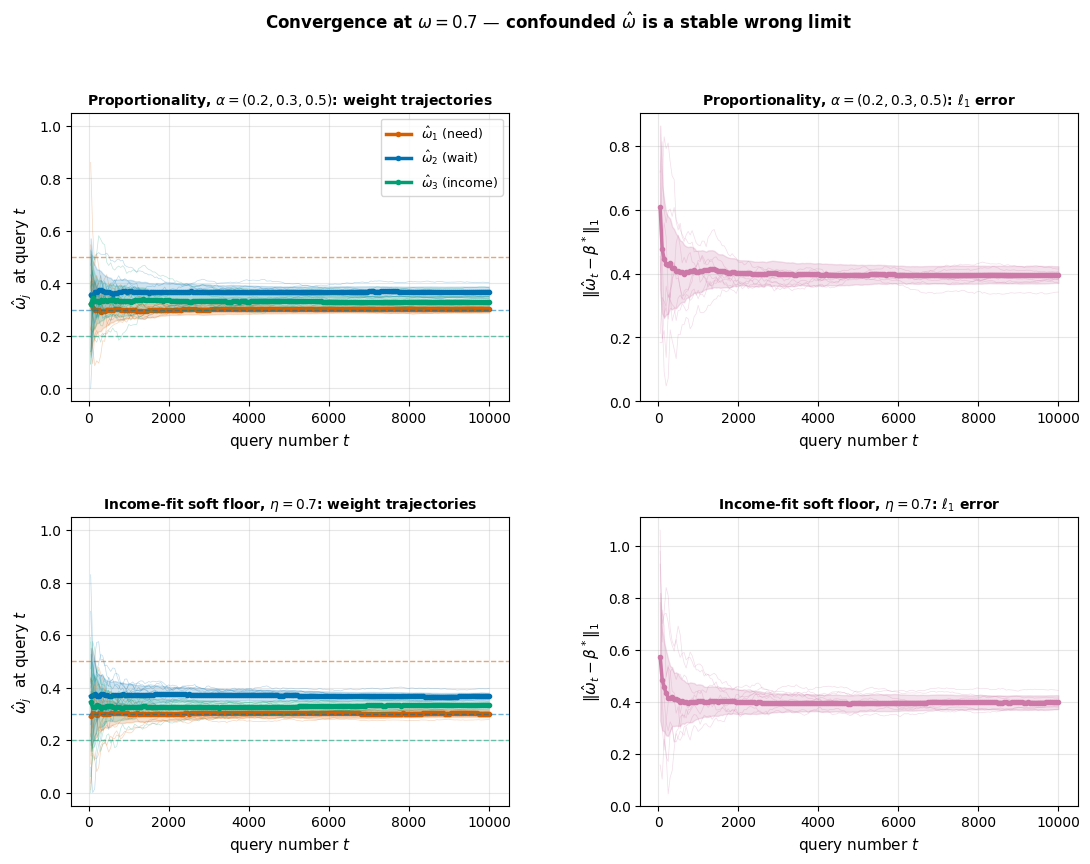


=== Final hat_omega and stability (after T=10000 queries) ===

u_C (ω=0, sanity):
  mean hat_omega:          [0.498 0.303 0.199]
  std across N_RUNS runs: [0.011 0.013 0.011]
  std/mean ratio:          [0.022 0.044 0.057]
  drift between t=9050 and t=10000: 0.0009

u_floor (ω=0, sanity):
  mean hat_omega:          [0.502 0.299 0.199]
  std across N_RUNS runs: [0.011 0.011 0.014]
  std/mean ratio:          [0.022 0.038 0.07 ]
  drift between t=9050 and t=10000: 0.0004

u_C (ω=0.7):
  mean hat_omega:          [0.302 0.369 0.33 ]
  std across N_RUNS runs: [0.013 0.019 0.021]
  std/mean ratio:          [0.043 0.052 0.065]
  drift between t=9050 and t=10000: 0.0007

u_floor (ω=0.7):
  mean hat_omega:          [0.301 0.367 0.333]
  std across N_RUNS runs: [0.013 0.014 0.015]
  std/mean ratio:          [0.044 0.038 0.045]
  drift between t=9050 and t=10000: 0.0010


In [60]:
# Convergence over queries — single weight, sweep T
def _convergence_run(omega_C, omega_floor, n_queries, n_inputs, seed,
                      query_checkpoints=None, alpha=None, eta=0.7):
    if alpha is None:
        alpha = ALPHA_C_DEFAULT
    rng = np.random.default_rng(seed)
    psi_raw = sample_psi_raw(rng, n_inputs, 3)
    psi = recode_psi(psi_raw)
    contribs = []
    if omega_C > 0:
        sp_n, sm_n = compute_s_C(psi_raw, alpha, rng)
        contribs.append((omega_C, sp_n, sm_n))
    if omega_floor > 0:
        sp_f, sm_f = compute_s_income_floor(psi, eta, rng)
        contribs.append((omega_floor, sp_f, sm_f))
    total = omega_C + omega_floor
    omega_sep = BETA_STAR_DEFAULT * (1 - total)
    xs = rng.integers(0, n_inputs, size=n_queries)
    resp = generate_responses(psi, xs, omega_sep, contribs, rng, LOGISTIC_SCALE_DEFAULT)
    deltas = sep_gap(psi)[xs]
    if query_checkpoints is None:
        query_checkpoints = list(range(50, n_queries + 1, 50))
    traj = np.zeros((len(query_checkpoints), 3))
    for ci, cp in enumerate(query_checkpoints):
        traj[ci] = fit_score_rum(deltas[:cp], resp[:cp], LOGISTIC_SCALE_DEFAULT)
    return query_checkpoints, traj


N_RUNS_CONV = 60
N_QUERIES_CONV = 10000
N_INPUTS_CONV = 800
OMEGA_FIXED = 0.7
checkpoints = list(range(50, N_QUERIES_CONV + 1, 50))

def _run_convergence(omega_C, omega_floor, seed_base):
    trajs = np.zeros((N_RUNS_CONV, len(checkpoints), 3))
    for r in range(N_RUNS_CONV):
        seed = seed_base + r * 17
        _, t = _convergence_run(omega_C, omega_floor, N_QUERIES_CONV,
                                 N_INPUTS_CONV, seed, checkpoints)
        trajs[r] = t
    return trajs

print(f"=== Convergence at ω={OMEGA_FIXED}, N_RUNS={N_RUNS_CONV}, T={N_QUERIES_CONV} ===")
print(f"u_C trajectories...")
trajs_uC = _run_convergence(OMEGA_FIXED, 0.0, 50000)
print(f"u_floor trajectories...")
trajs_uF = _run_convergence(0.0, OMEGA_FIXED, 60000)
# Sanity check: at omega=0 the learner should converge to beta* (no inseparable
# priority active). Use the same harness with both omegas zero — top and bottom
# rows of the figure will both show recovery of beta* if the implementation
# is correct.
print(f"\n=== Sanity check at ω=0.0, N_RUNS={N_RUNS_CONV}, T={N_QUERIES_CONV} ===")
print("u_C (off) trajectories...")
trajs_uC_sanity = _run_convergence(0.0, 0.0, 70000)
print("u_floor (off) trajectories...")
trajs_uF_sanity = _run_convergence(0.0, 0.0, 80000)



FEAT_NAMES_CV = [r"$\hat\omega_1$ (need)", r"$\hat\omega_2$ (wait)", r"$\hat\omega_3$ (income)"]


def _draw_convergence_row(axes_row, trajs, util_label, show_legend=False):
    """Draw a single utility's (trajectory, L1 error) convergence panels into two axes."""
    mean = trajs.mean(0); std = trajs.std(0)
    # Left: hat_omega over queries (thin individual runs + mean ± std)
    ax = axes_row[0]
    for j in range(3):
        for r in range(min(8, trajs.shape[0])):
            ax.plot(checkpoints, trajs[r, :, j], color=FEAT_COLORS[j], lw=0.5, alpha=0.25)
        ax.plot(checkpoints, mean[:, j], color=FEAT_COLORS[j], lw=2.5,
                marker='o', ms=3, label=FEAT_NAMES_CV[j])
        ax.fill_between(checkpoints, mean[:, j] - std[:, j], mean[:, j] + std[:, j],
                        color=FEAT_COLORS[j], alpha=0.18)
        ax.axhline(BETA_STAR_DEFAULT[j], color=FEAT_COLORS[j], ls='--', lw=1.0, alpha=0.55)
    ax.set_xlabel("query number $t$", fontsize=11)
    ax.set_ylabel(r"$\hat\omega_j$  at query $t$", fontsize=11)
    ax.set_ylim(-0.05, 1.05)
    ax.grid(alpha=0.3)
    if show_legend:
        ax.legend(fontsize=9, loc='upper right')
    ax.set_title(rf"{util_label}: weight trajectories", fontsize=10, fontweight='bold')

    # Right: L1 error over queries
    ax2 = axes_row[1]
    l1 = np.abs(trajs - BETA_STAR_DEFAULT[None, None, :]).sum(axis=2)
    l1_mean = l1.mean(0); l1_std = l1.std(0)
    for r in range(min(8, trajs.shape[0])):
        ax2.plot(checkpoints, l1[r], color='#CC79A7', lw=0.5, alpha=0.25)
    ax2.plot(checkpoints, l1_mean, color='#CC79A7', lw=2.5, marker='o', ms=3)
    ax2.fill_between(checkpoints,
                     np.maximum(l1_mean - l1_std, 0), l1_mean + l1_std,
                     color='#CC79A7', alpha=0.22)
    ax2.set_xlabel("query number $t$", fontsize=11)
    ax2.set_ylabel(r"$\|\hat\omega_t - \beta^*\|_1$", fontsize=11)
    ax2.set_ylim(0, None)
    ax2.grid(alpha=0.3)
    ax2.set_title(rf"{util_label}: $\ell_1$ error", fontsize=10, fontweight='bold')


def _convergence_figure(trajs_uC_in, trajs_uF_in, suptitle, save_path):
    fig, axes = plt.subplots(2, 2, figsize=(13, 9),
                              gridspec_kw=dict(wspace=0.30, hspace=0.40))
    _draw_convergence_row(
        axes[0], trajs_uC_in,
        util_label=r"Proportionality, $\alpha=(0.2,0.3,0.5)$",
        show_legend=True,
    )
    _draw_convergence_row(
        axes[1], trajs_uF_in,
        util_label=r"Income-fit soft floor, $\eta=0.7$",
        show_legend=False,
    )
    fig.suptitle(suptitle, y=0.995, fontsize=12, fontweight='bold')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


# Sanity-check figure: omega = 0 -> learner should recover beta*.
_convergence_figure(
    trajs_uC_sanity, trajs_uF_sanity,
    suptitle=r"Sanity check at $\omega = 0$ — no inseparable priority; $\hat\omega$ converges to $\beta^*$",
    save_path="uC_uFloor_convergence_sanity.png",
)

# Confounded figure: omega = OMEGA_FIXED.
_convergence_figure(
    trajs_uC, trajs_uF,
    suptitle=rf"Convergence at $\omega = {OMEGA_FIXED}$ — confounded $\hat\omega$ is a stable wrong limit",
    save_path="uC_uFloor_convergence.png",
)


# Final-trajectory stability check
print(f"\n=== Final hat_omega and stability (after T={N_QUERIES_CONV} queries) ===")
for name, trajs in [
    (r"u_C (ω=0, sanity)",     trajs_uC_sanity),
    (r"u_floor (ω=0, sanity)", trajs_uF_sanity),
    (rf"u_C (ω={OMEGA_FIXED})",     trajs_uC),
    (rf"u_floor (ω={OMEGA_FIXED})", trajs_uF),
]:
    final = trajs[:, -1, :]
    final_mean = final.mean(0); final_std = final.std(0)
    print(f"\n{name}:")
    print(f"  mean hat_omega:          {final_mean.round(3)}")
    print(f"  std across N_RUNS runs: {final_std.round(3)}")
    print(f"  std/mean ratio:          {(final_std / final_mean).round(3)}")
    # Stability of mean over last 500 queries
    late_mean = trajs[:, -10:, :].mean()
    early_mean = trajs[:, -20:-10, :].mean(0).mean(0)
    print(f"  drift between t={checkpoints[-20]} and t={checkpoints[-1]}: "
          f"{np.abs(trajs[:, -1, :].mean(0) - trajs[:, -20, :].mean(0)).max():.4f}")
